# Variational Quantum Circuits para clasificar iris dataset usando Data Re-uploading

En el proyecto de circuitos cuánticos variacionales se analizó distintas arquitecturas y dispositivos cuánticos para evaluar el desemepeño de un clasificador cuántico para el data set de iris. 

En este notebook se implementa una arquitectura de Data Re-uploading, que consiste en cargar los datos varias veces a lo largo del circuito usualmente más pequeño en el número de qubits, pero con más capas, es decir, con más repeticiones de la misma estructura. Esta metodología promete reducir la perdida de información debido a errores innatos a la era NISQ (Noisy Intermediate-Scale Quantum).

Algunas secciones serán exactamente iguales a las del proyecto de circuitos cuánticos variacionales. Por ejemplo, la carga de datos, exploración y preprocesamiento serán iguales. Sin embargo, la sección de construcción del circuito variacional y el entrenamiento serán diferentes. Las celdas asociadas a estas 3 secciones podrán saltarse si se desea, ya que el enfoque de este notebook es la arquitectura de Data Re-uploading.

**Notas importantes**

Una caracterítica sobresaliente de esta arquitectura es que require menos qubit. Es decir, si tenemos un dataset con $n$ caracteríticas, se busca reducir el tamaño del circuito a $m$ qubits, con $m < n$. Esto se logra cargando la información de las caracteríticas de manera secuencial a lo largo del circuito, a lo largo de cada qubit. De esta manera, se puede reducir el número de qubits necesarios para representar la información del dataset, lo que es especialmente útil en la era NISQ donde el número de qubits disponibles es limitado y los errores son comunes.

Uno podría pensar ¿cuál es el sentido físico de ingresar secuencialmente la información de cada feature en menos qubits respecto a la cantidad de variables? ¿no sería proyecta un espacio de mayor dimensión a un espacio de menor dimensión, lo cual suele perder información? La respuesta es que no hay proyección, sino que se reingresa la información a lo largo del circuito. Es decir, se carga la información de cada feature en el mismo qubit varias veces a lo largo del circuito, lo que permite que la información se propague a través de las capas del circuito y se mantenga la relevancia de cada feature a lo largo del proceso de clasificación.

Otra pregunta importante es ¿existe alguna diferencia en la secuencia de ingreso de información? Para responder esto recordemos que las compuertas de rotación son matrices unitarias que actúan sobre el estado cuántico de los qubits. Además estas matrices no son conmutativas, es decir, el orden de aplicación de las compuertas afecta el resultado final. Por lo tanto, la secuencia de ingreso de información a través de las compuertas de rotación puede influir en cómo se procesa la información y, en consecuencia, en el rendimiento del modelo. 

Respecto al **entrelazamiento**. En una arquitectura de varios qubits usamos compuertas controladas para entrelazar qubits, aquí, para emular este entrelazamiento usaremos el estado final del qubit.

### Evolución del estado cuántico a lo largo del circuito

Después de esta breve introducción se desarrollará la evolución del estado cuántico a lo largo del circuito.

**Estado inicial**

El estado inicial, $\ket{\psi _0}$, será el estado base de todos los qubits, es decir, el estado $|0\rangle$.

**Carga de datos**

Una vez que inicializamos el qubit, codificaremos los datos clásicos por medio de una compuerta de rotación, es decir, se usará angle encoding. Esta compuerta tendrá como parámetro la información normalizada de cada caracterítica, $S(x_i)$.

**Anzats**

Después de cargar los datos, se aplicará una capa de rotaciones parametrizadas, es decir, una capa de variación. Esta capa tendrá como parámetros $\theta$, que serán los parámetros a optimizar durante el entrenamiento del modelo. En este punto el estado tendrá la forma:
$$\ket{\psi} = A_i (\theta) S(x_i) \ket{\psi_0}$$

**Reingreso de datos**

Después de aplicar la capa de variación, se volverá a cargar la información de las caracteríticas por medio de otra capa de rotaciones. Esta capa tendrá como parámetro la información normalizada de cada caracterítica, $S(x_i)$, al igual que la primera capa de carga de datos. A continuación se volverá a aplicar el anzats para la nueva feature y continuaremos así hasta la última característica. En este punto el estado tendrá la forma:

\begin{equation}
\begin{aligned}
    \ket{\psi} &=
         A_2 (\theta_2) S(x_2) A_1 (\theta_1) S(x_1) \ket{\psi_0} \\
        &= \prod_{i=1}^n A_i (\theta_i) S(x_i) \ket{\psi_0}
\end{aligned}
\end{equation}

**Medición**

A la hora de medir usaremos una compuerta PauliZ en el primer quibit para obtener la probabilidad de la clase.
Lo cual se ve reflejado en la siguiente expresión:
$$\langle \hat{Z} \rangle = \bra{\psi} \hat{Z} \ket{\psi}$$

## Carga de datos y exploración inicial

El dataser de iris es un conjunto de datos clásico en el aprendizaje automático, que contiene información sobre las características de diferentes tipos de flores de iris. Este dataset se utiliza comúnmente para tareas de clasificación, donde el objetivo es predecir la especie de iris basada en sus características.
Los variables de entrada.

Primero se cargan las librerías que usaremos a priori, luego se carga el dataset de iris utilizando la función `load_iris` de `sklearn.datasets`.

In [ ]:
# librerías necesarias
import pennylane as qml
from pennylane import numpy as np

from sklearn.datasets import load_iris6
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, auc, roc_curve

import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# Cargamos el dataset de iris
iris_data = load_iris()

In [4]:
# tipo de objeto
type(iris_data)

sklearn.utils._bunch.Bunch

Vemos los comportentes del dataset

In [5]:
iris_data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [6]:
for key in iris_data.keys():
    print(f"{key}: {type(iris_data[key])}")

data: <class 'numpy.ndarray'>
target: <class 'numpy.ndarray'>
frame: <class 'NoneType'>
target_names: <class 'numpy.ndarray'>
DESCR: <class 'str'>
feature_names: <class 'list'>
filename: <class 'str'>
data_module: <class 'str'>


Los valores del dataset son: 
- 'data': valores de las características de las flores
- 'target': etiquetas de las especies de iris
- 'frame': marco de datos (si está disponible)
- 'target_names': nombres de las especies de iris
- 'DESCR': descripción del dataset
- 'feature_names': nombres de las características
- 'filename': nombre del archivo del dataset
- 'data_module': módulo de datos (si está disponible)

Para entender mejor el dataset, podemos cargarlo en un dataframe de pandas y explorar su estructura y contenido. Esto nos permitirá visualizar las características de las flores de iris y cómo se relacionan con las diferentes especies.

## Exploración de datos

In [7]:
# mostramos DESCR del dataset
print(iris_data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [8]:
# Cargamos un dataframe con los datos de iris
iris_df = pd.DataFrame(data=iris_data.data, columns=iris_data.feature_names)

In [9]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [10]:
iris_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


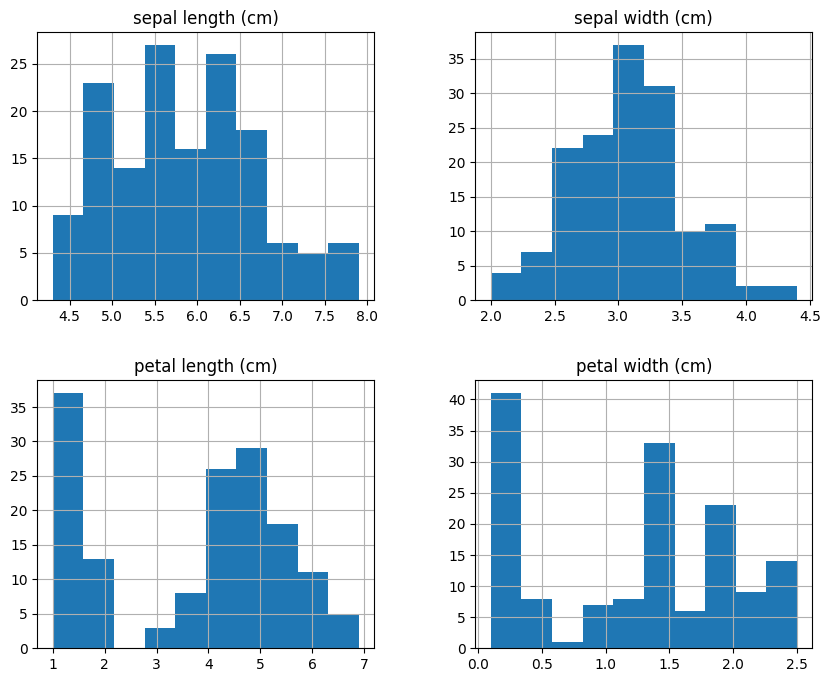

In [11]:
# hitograma de las características
iris_df.hist(figsize=(10, 8))
plt.show()

Viendo los histogramas hay un comportamiento bimodal en petal length y petal width, lo que sugiere que estas características pueden ser útiles para distinguir entre las diferentes especies de iris. Además, se observa que la longitud del sépalo y el ancho del sépalo tienen una distribución más uniforme, lo que podría indicar que son menos discriminativas para la clasificación de las especies de iris.

Ahora veamos un poco más de la descripción de los datos. Se verá la dispersión de los datos con un pairplot, y se verá la correlación entre las características con un heatmap. Esto nos ayudará a entender mejor las relaciones entre las características y cómo pueden influir en la clasificación de las especies de iris.

In [12]:
import seaborn as sns

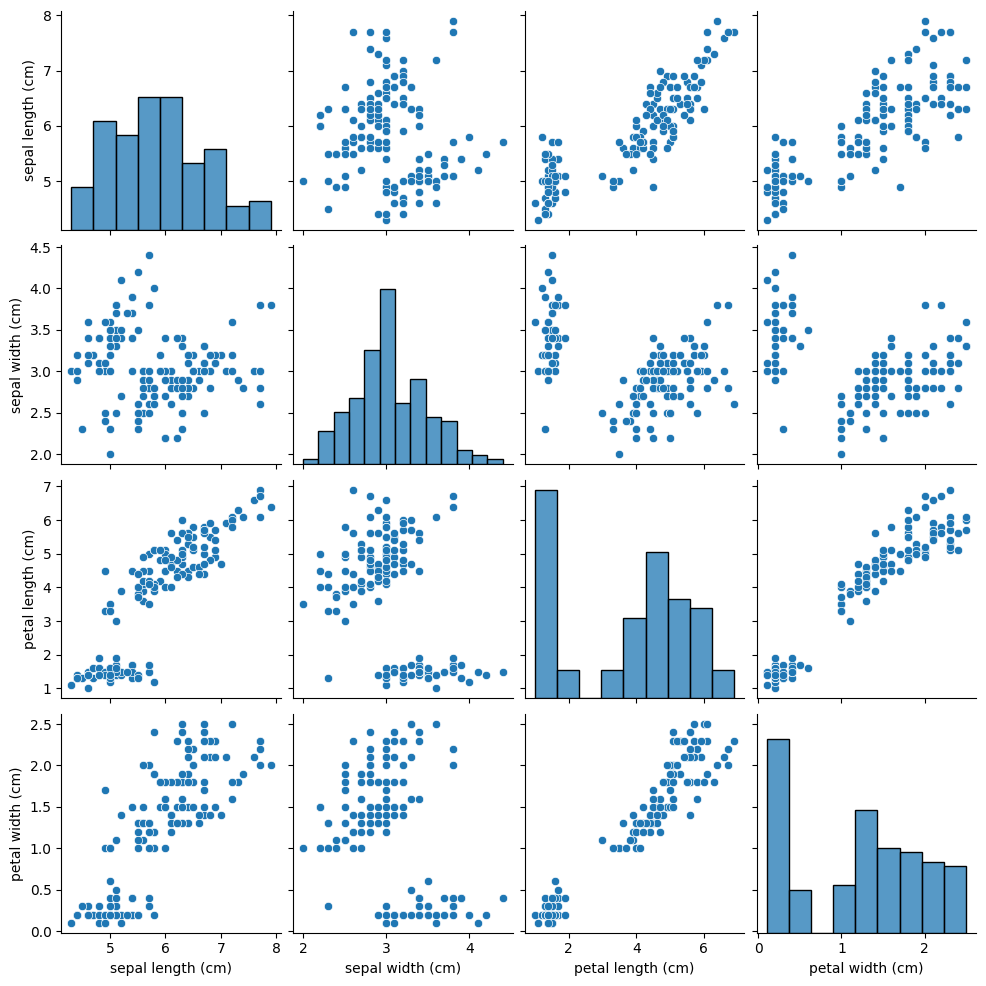

In [13]:
# pairplot de las características
sns.pairplot(iris_df,
             diag_kind='hist'
             )
plt.show()

A primera vista podemos que ver hay una correlación entre petal length y petal width, lo que sugiere que estas dos características están relacionadas y podrían ser útiles para la clasificación de las especies de iris. Otras caracteríticas que podrían tener correlación son sepal legth con petal length y petal width con petal lenght.

Por otro lado, respecto a los histogramas, se observa que la longitud del sépalo y el ancho del sépalo tienen una distribución más uniforme, lo que podría indicar que son menos discriminativas para la clasificación de las especies de iris. 

Ahora veamos la matriz de correlación con un heatmap para entender mejor las relaciones entre las características.

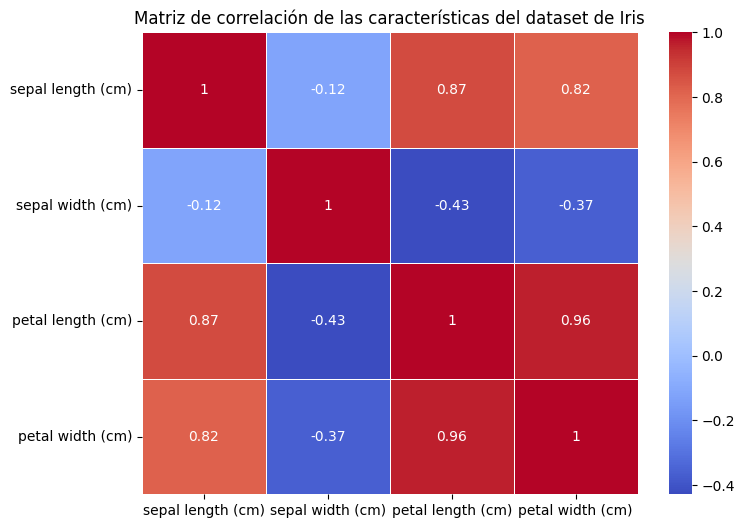

In [14]:
# Matriz de correlación con un heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(iris_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de correlación de las características del dataset de Iris')
plt.show()

Esto confirma las visualizaciones anteriores con datos numéricos. Veamos las más relevantes:
- **Correlación entre petal length y petal width**: La correlación es muy alta (0.96), lo que indica que estas dos características están fuertemente relacionadas. Esto sugiere que podrían ser muy útiles para la clasificación de las especies de iris. Esta correlación podría deberse a que ambas características están relacionadas con el tamaño del pétalo de la flor, lo que es un factor importante para distinguir entre las especies.
- **Correlación entre sepal length y petal length**: La correlación es moderada (0.87), lo que indica que estas características también están relacionadas, aunque no tan fuertemente como petal length y petal width. Esto sugiere que sepal length también podría ser útil para la clasificación, pero quizás no tanto como petal length.
- **Correlación entre petal width y sepal length**: La correlación es moderada (0.82), lo que indica que estas características también están relacionadas, aunque no tan fuertemente como petal length y petal width. Esto sugiere que sepal length también podría ser útil para la clasificación, pero quizás no tanto como petal width.

En el contexto de los circuitos cuánticos variacionales, estas correlaciones pueden ser importantes para seleccionar las características que se utilizarán como entrada para el modelo. Por ejemplo, podríamos elegir usar petal length y petal width como características principales debido a su alta correlación, lo que podría mejorar el rendimiento del modelo de clasificación. Respecto al anzats, podríamos diseñar un circuito cuántico que aproveche estas correlaciones para aprender a clasificar las especies de iris de manera más eficiente, posiblemente aplicando compuertas controladas para entrelazar las características que están altamente correlacionadas.

## Preprocesamiento de datos

In [15]:
# visualizamos algunos elementos de las etiquetas
print(iris_data.target[::2])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2]


In [16]:
# cargamos los datos de las características y las etiquetas
X = iris_data.data
y = iris_data.target

Para este primer proyecto de quanutm machine learning se usará solo una salida binaria, es decir, se clasificará entre dos especies de iris. Para esto, se seleccionarán solo las muestras correspondientes a dos especies específicas y se asignarán etiquetas binarias (-1 y 1) para cada especie. Además, se normalizarán las características para que tengan una escala similar, lo que puede ayudar a mejorar el rendimiento del modelo de clasificación.

In [17]:
print(X.shape, y.shape)

(150, 4) (150,)


In [18]:
X = X[y != 2]  # Seleccionamos solo las muestras de las dos primeras clases
y = y[y != 2]  # Seleccionamos solo las etiquetas de las dos

In [19]:
# convertimos las etiquetas a -1 y 1
y = np.where(y == 0, -1, 1)
print(X.shape, y.shape)

(100, 4) (100,)


Para la parte de normalización, se utilizará `MinMaxScaler` de `sklearn.preprocessing`, que escala las características para que estén en un rango específico, en este caso, entre 0 y π. Este rango es utilizado porque se usarán compuertas de rotación en el circuito cuántico, que suelen tomar ángulos en este rango. Normalizar las características de esta manera puede ayudar a mejorar la convergencia del modelo durante el entrenamiento y a evitar problemas relacionados con la escala de los datos.

In [20]:
# normalizamos las características para que estén en el rango [0, π]
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X)

Notemos que tenemos en total 100 muestras, un número relativamente pequeño. Para nuestro entrenamiento tomaremos 70 muestras para entrenamiento, 15 para validación y 15 para test. Esto nos permitirá evaluar el rendimiento del modelo de manera adecuada, aunque es importante tener en cuenta que con un número tan pequeño de muestras, el modelo podría no generalizar bien a datos nuevos. Por lo tanto, es crucial realizar una validación cuidadosa y considerar técnicas adicionales como la regularización o el aumento de datos si es necesario para mejorar la capacidad de generalización del modelo.

In [21]:
random_state = 42

In [22]:
# Dividimos los datos
X_train, X_val_test, y_train, y_val_test = train_test_split(X_scaled, y, 
                                                            test_size=0.3, 
                                                            random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, 
                                                y_val_test, 
                                                test_size=0.5, 
                                                random_state=random_state)

In [23]:
# visualizamos los datos de entrenamiento
print("Algunos datos de entrenamiento:")
print(X_train[:5])
print(y_train[:5])

Algunos datos de entrenamiento:
[[0.58177642 1.83259571 0.45974527 0.18479957]
 [0.34906585 1.57079633 0.30649684 0.18479957]
 [1.97803982 1.83259571 2.68184739 2.77199352]
 [1.04719755 1.83259571 0.30649684 0.18479957]
 [0.81448698 0.39269908 1.76235685 1.66319611]]
[-1 -1  1 -1  1]


In [24]:
# Tamaño de los conjuntos de datos
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de validación: {X_val.shape[0]} muestras")
print(f"Tamaño del conjunto de test: {X_test.shape[0]} muestras")

Tamaño del conjunto de entrenamiento: 70 muestras
Tamaño del conjunto de validación: 15 muestras
Tamaño del conjunto de test: 15 muestras


## Modelos

Primero visualizamos los datos de entrenamiento para asegurarnos de que se han preprocesado correctamente y para tener una idea de cómo se ven las características normalizadas. Esto nos permitirá verificar que las características están en el rango esperado y que las etiquetas están asignadas correctamente.

In [25]:
# Visualizamos el dataset de entrenamiento como tabla
train_df = pd.DataFrame(X_train, columns=iris_data.feature_names)
train_df['label'] = y_train
columns = {'sepal length (cm)': 'sepal_length_norm',
           'sepal width (cm)': 'sepal_width_norm',
           'petal length (cm)': 'petal_length_norm',
           'petal width (cm)': 'petal_width_norm'}
train_df.rename(columns=columns, inplace=True)
train_df.head()

,sepal_length_norm,sepal_width_norm,petal_length_norm,petal_width_norm,label
0,0.581776,1.832596,0.459745,0.184800,-1
1,0.349066,1.570796,0.306497,0.184800,-1
2,1.978040,1.832596,2.681847,2.771994,1
3,1.047198,1.832596,0.306497,0.184800,-1
4,0.814487,0.392699,1.762357,1.663196,1


Veamos nuevamente la matriz de correlacion

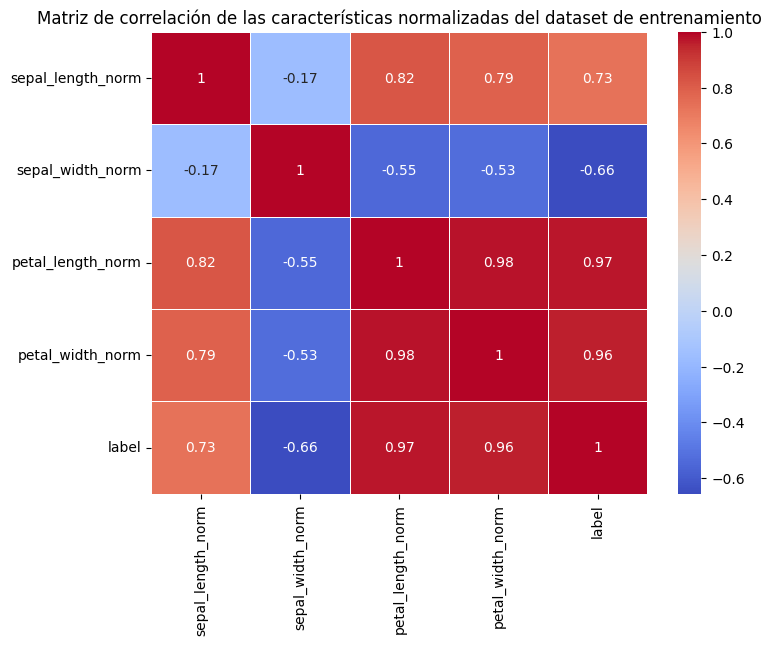

In [26]:
# Matriz de correlación con un heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de correlación de las características normalizadas del dataset de entrenamiento')
plt.show()

Recordemos que los valores iniciales con mayor correlación son
1. petal length y petal width (0.96)
2. sepal length y petal length (0.87), y 
3. petal width y sepal length (0.82)

Esto representa las relaciones
- [2, 3] para petal length y petal width
- [0, 2] para sepal length y petal length
- [3, 0] para petal width y sepal length

Con la información de la matriz de correlación del conjunto de entranamiento cambiaron algunos valores, pero el orden de correlación se mantiene. Esto es importante porque nos da una idea de qué características podrían ser más relevantes para la clasificación de las especies de iris.

### Modelos sin ruido

#### Estructura general del circuito cuántico variacional

In [27]:
# definimos el dispositivo cuántico
n_qubits = X_train.shape[1]  # número de características
dev = qml.device('default.qubit', wires=n_qubits)

# Feature map: codificación de los datos en el estado cuántico
def feature_map(x):
    # Usamos angle encoding, que es una forma común de codificar datos en un circuito cuántico
    for i in range(len(x)):
        qml.RY(x[i], wires=i)

# Creamos el Ansatz del circuito cuántico
def ansatz(params, arquitecture=1):
    # Aplicamos una capa de compuertas de rotación parametrizadas
    for i in range(n_qubits):
        qml.RX(params[i, 0], wires=i)
        qml.RY(params[i, 1], wires=i)

    # Selección de arquitectura
    if arquitecture == 1:
        # Solo entrelazamiento entre petal length y petal width
        qml.CNOT(wires=[2,3])  # entrelazamiento entre petal length y petal width
    elif arquitecture == 2:
        # Entre los dos pares de valores de correlación más altos
        qml.CNOT(wires=[0, 2])  # entrelazamiento entre sepal length y petal length
        qml.CNOT(wires=[2, 3])  # entrelazamiento entre petal length y petal width
    elif arquitecture == 3:
        # Completamente entrelazada
        for i in range(n_qubits):
            for j in range(i+1, n_qubits):
                qml.CNOT(wires=[i, j])
    elif arquitecture == 4:
        # Solo entrelazada donde la correlación tiende a 0, es decir, entre sepal length y sepal width ([0, 1])
        qml.CNOT(wires=[0, 1])  # entrelazamiento entre sepal length y sepal width
        
    # Conectamos en cascada hacia el primer qubit para que la información de todas las características se mezcle
    for i in range(1, n_qubits):
        qml.CNOT(wires=[i, 0])

In [28]:
# Creamos el circuito cuántico completo
@qml.qnode(dev)
def quantum_circuit(x, params, arquitecture=1):
    feature_map(x)
    ansatz(params, arquitecture)
    # Medimos el valor esperado de Z en el primer qubit para obtener la probabilidad de la clase
    return qml.expval(qml.PauliZ(0))

In [29]:
# pesos aleatorios para el ansatz
params = 0.01*np.random.rand(n_qubits, 2, requires_grad=True)

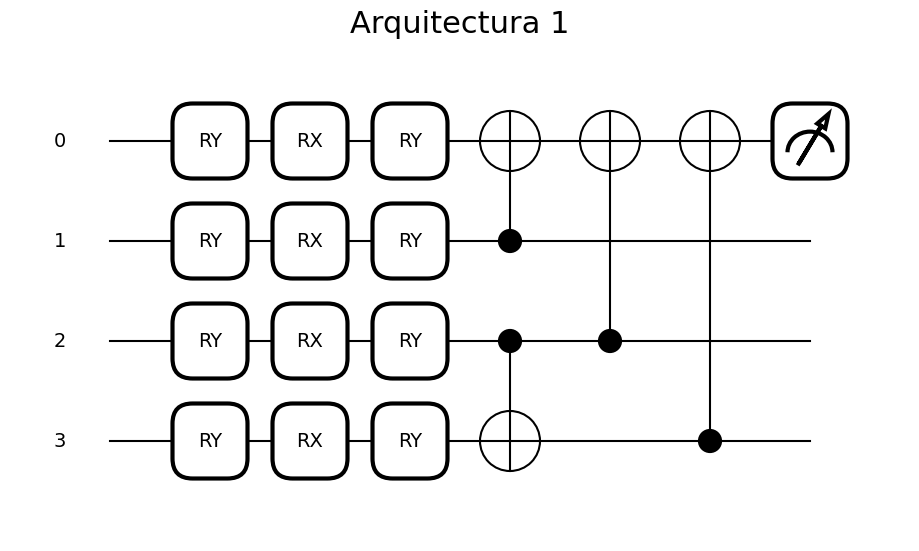

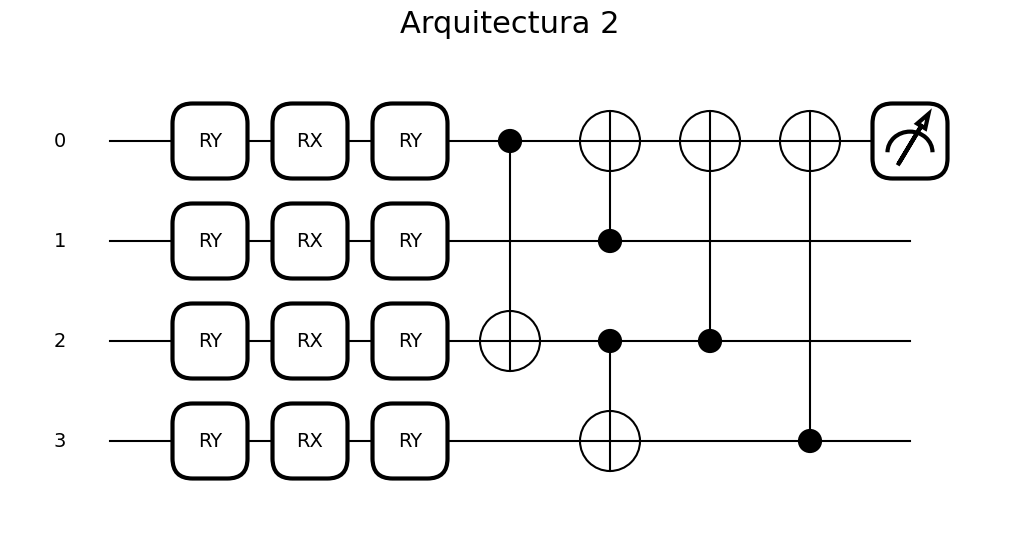

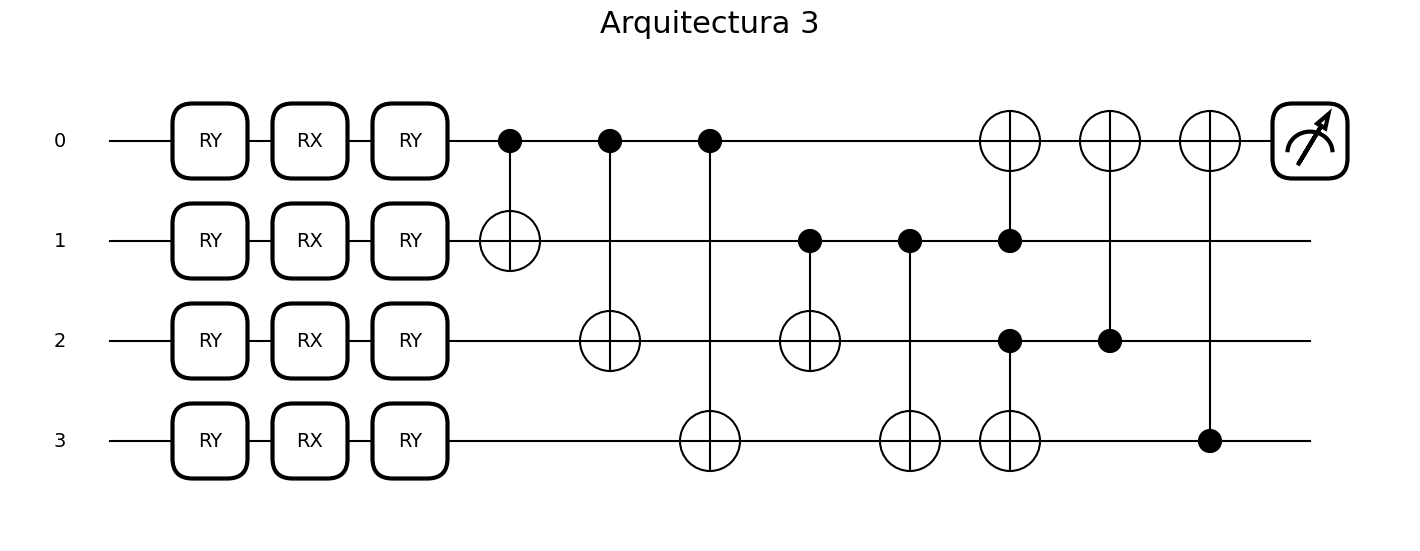

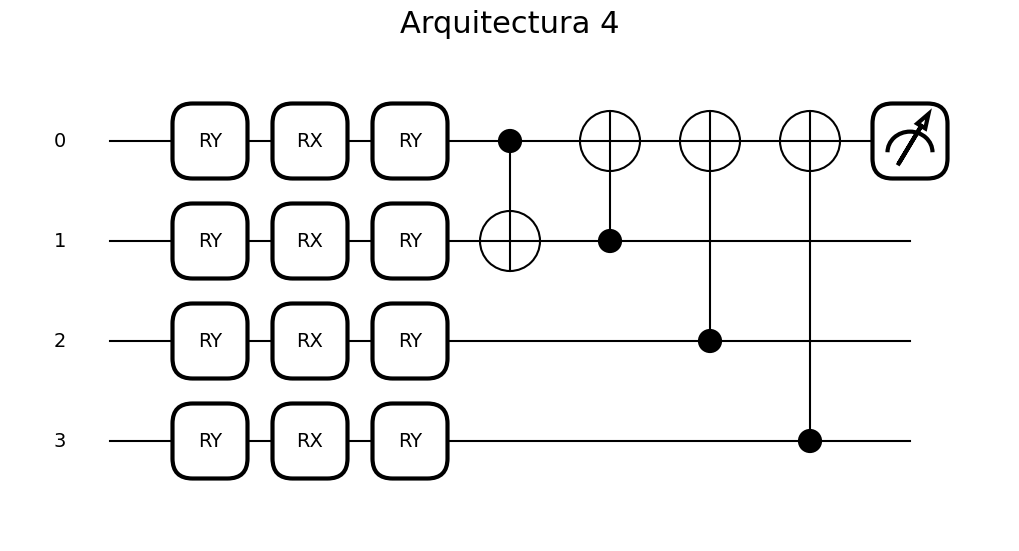

In [30]:
# visuazlizamos las arquitecturas del circuito cuántico
for arquitecture in range(1, 5):
    fig, ax = qml.draw_mpl(quantum_circuit)(X_train[0], params, arquitecture=arquitecture)
    ax.set_title(f"Arquitectura {arquitecture}", fontsize=22)
    plt.show()

#### Funciones adicionales

Como mis etiquetas están en el rango de [-1, 1], y la salida de PauliZ está en el rango de [-1, 1], puedo usar la función de costo de error cuadrático medio (MSE) para evaluar el rendimiento del modelo. Esta función de costo mide la diferencia entre las etiquetas reales y las predicciones del modelo, penalizando más los errores grandes. Al minimizar esta función de costo durante el entrenamiento, el modelo aprenderá a hacer predicciones más precisas para clasificar las especies de iris.

In [31]:
# Función de costo
def cost_function(params, input_data, labels, arquitecture=1):
    """
    Función de costo para el modelo cuántico. Se usa 
    el error cuadrático medio entre las predicciones del circuito 
    cuántico y las etiquetas verdaderas.
    
    Args:
        params: Parámetros del circuito cuántico.
        input_data: Datos de entrada.
        labels: Etiquetas verdaderas.
        arquitecture: Arquitectura del circuito cuántico.
    
    Returns:
        Costo medio cuadrático entre las predicciones y las etiquetas.
    """
    predictions = [quantum_circuit(x, params, arquitecture) for x in input_data]
    return np.mean((np.array(predictions) - np.array(labels))**2)

Ahora definimos la función para calcular el accuracy del modelo.

In [32]:
# Calculo de accuracy
def accuracy(labels, predictions):
    """
    Calcula la precisión (accuracy) del modelo.

    args:
        labels: las etiquetas reales de las muestras
        predictions: las predicciones del modelo para las muestras
    return:
        La precisión del modelo, que es el porcentaje de predicciones correctas.
    """
    # Si la predicción es mayor o igual a 0, se clasifica como 1, de lo contrario se clasifica como -1
    predictions = [1.0 if p>= 0 else -1.0 for p in predictions]
    correct = sum([1.0 if labels[i] == predictions[i] else 0.0 for i in range(len(labels))])
    return correct / len(labels)

# Función manual Auc y curva ROC
def auc_manual(labels, predictions):
    """
    Calcula el área bajo la curva ROC (AUC) de forma manual.
    args:
        labels: las etiquetas reales de las muestras
        predictions: las predicciones del modelo para las muestras
    return:
        El valor del AUC, que es una medida de la capacidad del modelo para distinguir entre las clases positivas y negativas.
    """
    # Separamos las predicciones en positivas y negativas
    positivas = [p for i, p in enumerate(predictions) if labels[i] == 1]
    negativas = [p for i, p in enumerate(predictions) if labels[i] == -1]

    # si falta una clase
    if not positivas or not negativas:
        return 0.5  # AUC es 0.5 si no hay una clase

    # Contamos el número de pares positivos-negativos
    ganadas = 0
    empates = 0
    total_pares = len(positivas) * len(negativas)

    for p in positivas:
        for n in negativas:
            if p > n:
                ganadas += 1
            elif p == n:
                empates += 1

    # Calculamos el AUC
    return (ganadas + empates) / total_pares


### Modelos con ruido

En esta segunda sección se verá cómo afecta el ruido a los modelos de clasificación. Para esto, se introducirá un modelo de ruido en el circuito cuántico variacional, lo que simulará las condiciones reales de un dispositivo cuántico, donde el ruido es una preocupación importante. El medio por que cual se introducirá el ruido será por medio de un dispositivo *mixto*, es decir, se usará `default.mixed` de `pennylane` para simular un dispositivo cuántico que incluye ruido.
Usaremos distintos porcentajes de **ruido**, con **0.005, 0.01 y 0.05**. Esto nos permitirá evaluar cómo el rendimiento del modelo de clasificación se ve afectado por diferentes niveles de ruido, lo que es crucial para entender la robustez del modelo en condiciones reales.

Primero se creará un circuito cuántico variacional con ruido utilizando `default.mixed` de `pennylane`.

In [33]:
# definimos el dispositivo cuántico con ruido
dev_noise = qml.device('default.mixed', wires=n_qubits)

# creamos el qnode con ruido
@qml.qnode(dev_noise)
def quantum_model_noise(input_data, params, arquitecture, noise_prob=0.02):
    feature_map(input_data)

    # Aplicamos el ruido a cada qubit
    if noise_prob > 0:
        for i in range(n_qubits):
            qml.DepolarizingChannel(noise_prob, wires=i)

    ansatz(params, arquitecture)

    # Medimos el valor esperado de Z en el primer qubit para obtener la probabilidad de la clase
    return qml.expval(qml.PauliZ(0))

Usaremos los mismo 4 circuitos que antes pero ahora con ruido.

## Entrenamiento y evaluación

Toca crear el bucle de entrenamiento.

In [34]:
import time

In [35]:
def entrenamiento(arquitecture, 
                  lr, weights, 
                  train_set, 
                  val_set, 
                  epochs=50, 
                  batch_size = 16, 
                  delta=0.01, 
                  epochs_sin_mejor_peso=10,
                  model_func = quantum_circuit):
    """
    Función de entrenamiento del modelo.
    Args:
        arquitecture: descripción de la arquitectura del modelo
        lr: tasa de aprendizaje para el optimizador
        weights: pesos iniciales del modelo
        train_set: conjunto de datos de entrenamiento (X_train, y_train)
        val_set: conjunto de datos de validación (X_val, y_val)
        epochs: número de épocas para el entrenamiento
        batch_size: tamaño del minibatch para el entrenamiento
        delta: umbral para considerar una mejora en el costo de validación
        epochs_sin_mejor_peso: número de épocas sin mejora para activar el early stopping
    Returns:
        best_weights: los mejores pesos encontrados durante el entrenamiento
        history_cost_train: lista con el costo de entrenamiento por época
        history_cost_val: lista con el costo de validación por época
        history_acc: lista con la precisión por época
        history_auc: lista con el AUC por época
    """
    print(f"Iniciando entrenamiento de la arquitectura {arquitecture}...")
    start_time = time.time()
    #optimizador
    opt = qml.AdamOptimizer(stepsize=lr)
    # Separamos los datos de entrenamiento en características y etiquetas
    X_train = train_set[0]
    y_train = train_set[1]
    # Separamos los datos de validación en características y etiquetas
    X_val = val_set[0]
    y_val = val_set[1]

    # Listas de pesos, costos y accuracies
    best_weights = None
    history_cost_val = []
    history_cost_train = []
    history_acc = []
    history_auc = []
    val_loss = float('inf')
    epoc_sin_mejor_peso = 0
    min_loss = float('inf')

    # pesos iniciales

    for epoch in range(epochs):
        loss_train = []
        # Entrenamiento con minibatches aleatorios
        for i in range(0, len(X_train), batch_size):
            X_batch = X_train[i:i+batch_size]
            y_batch = y_train[i:i+batch_size]
            # Actualizamos los parámetros del modelo usando el optimizador
            weights = opt.step(lambda w: cost_function(w, X_batch, y_batch, arquitecture), weights)

            # Evaluación del desempeño en el conjunto de entrenamiento
            predictions_train = [model_func(x, weights, arquitecture) for x in X_batch]
            costo_train = cost_function(weights, X_batch, y_batch, arquitecture)

            loss_train.append(costo_train)

        # Desempeño por época del conjunto de entrenamiento
        history_cost_train.append(np.mean(loss_train))

        # Evaluación de desempeño con el conjunto de validación
        predictions_val = [model_func(x, weights, arquitecture) for x in X_val]
        costo_actual_val = cost_function(weights, X_val, y_val, arquitecture)
        accu_acual = accuracy(y_val, predictions_val)

        # Guardamos históricos de evaluación de validación
        history_cost_val.append(costo_actual_val)
        history_acc.append(accu_acual)

        # Calculamos el AUC para el conjunto de validación
        auc_val = auc_manual(y_val, predictions_val)
        history_auc.append(auc_val)

        # Imprimimos el progreso cada 5 épocas
        if epoch % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs}: train_loss: {history_cost_train[epoch]:.4f} - val_loss: {costo_actual_val:.4f} - accuracy: {accu_acual:.4f} - auc: {auc_val:.4f}")

        # Guardamos los mejores pesos basados en el costo de validación
        if epoch == 0:
            best_weights = weights
            min_loss = costo_actual_val
        elif costo_actual_val + delta < min_loss:
            best_weights = weights
            min_loss = costo_actual_val
            print(f"Mejores pesos actualizados en epoch {epoch+1}: val_loss {costo_actual_val:.4f} - accuracy {accu_acual:.4f} - AUC {auc_val:.4f}")

        # Early stopping basado en el costo de validación
        # Se dentendrá si el costo no mejora después de epochs_sin_mejor_peso épocas y el costo actual es mayor que el mínimo histórico
        if epoch > 0 and costo_actual_val >= min_loss + delta:
            epoc_sin_mejor_peso += 1
            if epoc_sin_mejor_peso >= epochs_sin_mejor_peso:
                print(f"Early stopping en epoch {epoch+1} - No se ha mejorado el costo de validación después de {epochs_sin_mejor_peso} épocas.")
                break
        else:
            epoc_sin_mejor_peso = 0


    end_time = time.time()
    print(f"Entrenamiento completado en {end_time - start_time:.2f} segundos.")
    return best_weights, history_cost_train, history_cost_val, history_acc, history_auc

In [36]:
# Función de gráfica de costo para entrenamiento y validación
def plot_cost(history_cost_train, history_cost_val, arquitecture):
    """
    Función para graficar el costo de entrenamiento y validación a lo largo de las épocas.
    args:
        history_cost_train: lista con el costo de entrenamiento por época
        history_cost_val: lista con el costo de validación por época
        arquitecture: descripción de la arquitectura del modelo
    return:
        Una gráfica que muestra la evolución del costo de entrenamiento y validación a lo largo de las épocas.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(history_cost_train, label='Costo de entrenamiento')
    plt.plot(history_cost_val, label='Costo de validación')
    plt.title(f'Costo de entrenamiento y validación - Arquitectura {arquitecture}', fontsize=16)
    plt.xlabel('Épocas', fontsize=14)
    plt.ylabel('Costo', fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()

In [37]:
# función para grafiacr la matriz de confusión usando el conjunto de test

def plot_confusion_matrix(labels, X_test, best_weights, arquitecture):
    """
    Función para graficar la matriz de confusión utilizando el conjunto de test.
    args:
        labels: las etiquetas reales de las muestras del conjunto de test
        X_test: características del conjunto de test
        best_weights: los mejores pesos encontrados durante el entrenamiento
        arquitecture: descripción de la arquitectura del modelo
    return:
        Una gráfica que muestra la matriz de confusión, que es una herramienta para evaluar el desempeño
        del modelo en términos de verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos.
    """

    # Obtener predicciones del circuito
    raw_predictions = [quantum_circuit(x, best_weights, arquitecture) for x in X_test]
    
    #  Convertir a etiquetas numéricas (-1, 1)
    predictions_num = [1.0 if p >= 0 else -1.0 for p in raw_predictions]
    
    # Mapeo de números a nombres reales
    target_names = {-1.0: 'Setosa', 1.0: 'Versicolor'}
    
    y_actual = [target_names[float(l)] for l in labels]
    y_pred = [target_names[float(p)] for p in predictions_num]

    # Crear la matriz usando nombres de texto
    # Definimos el orden de las categorías para que la matriz sea consistente
    categories = ['Setosa', 'Versicolor']
    df_cm = pd.crosstab(
        pd.Series(y_actual, name='Actual'), 
        pd.Series(y_pred, name='Predicted'),
        dropna=False
    ).reindex(index=categories, columns=categories, fill_value=0)

    # Graficar
    plt.figure(figsize=(7, 6))
    sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    
    plt.title(f'Matriz de confusión - Arquitectura {arquitecture}', fontsize=14, pad=20)
    plt.xlabel('Predicción del modelo', fontsize=12)
    plt.ylabel('Clase real', fontsize=12)
    plt.show()

In [38]:
# Función para evaluar en el conjunto test

def evaluate_test_set(best_weights, X_test, y_test, arquitecture):
    """
    Función para evaluar el desempeño del modelo en el conjunto de test utilizando los mejores pesos encontrados durante el entrenamiento.
    args:
        best_weights: los mejores pesos encontrados durante el entrenamiento
        X_test: características del conjunto de test
        y_test: etiquetas del conjunto de test
        arquitecture: descripción de la arquitectura del modelo
    """
    # predicciones con el conjunto de test usando los mejores pesos encontrados durante el entrenamiento
    predictions_test = [quantum_circuit(x, best_weights, arquitecture) for x in X_test]

    # Evaluación del desempeño en el conjunto de test
    costo_test = cost_function(best_weights, X_test, y_test, arquitecture)
    accuracy_test = accuracy(y_test, predictions_test)
    auc_test = auc_manual(y_test, predictions_test)

    print(f"Test loss: {costo_test:.4f} - Test accuracy: {accuracy_test:.4f} - Test AUC: {auc_test:.4f}")


### Modelos sin ruido

Para los modelos son ruido dejaremos el parámetros por default del número de epocas para activar el early stopping en 10 épocas, por ello no estará explícitamente en la función de entrenamiento. Esto significa que el entrenamiento se detendrá si el costo de validación no mejora después de 10 épocas consecutivas, lo que ayuda a prevenir el sobreajuste y a ahorrar tiempo de entrenamiento.

#### Arquitectura 1: Solo entrelazamiento entre petal length y petal width

In [39]:
# hiperparámetros
n_iterations = 50
batch_size = 16
learning_rate = 0.01
weights = 0.01*np.random.rand(n_qubits, 2, requires_grad=True)
delta = 0.05

# arquitectura a entrenar
arquitecture = 1

In [40]:
# Entrenamiento del modelo con arquitecrura 1
best_weights_arq1, history_cost_train_arq1, history_cost_val_arq1, history_acc_arq1, history_auc_arq1 = entrenamiento(arquitecture,
                                                                                                  learning_rate, 
                                                                                                  weights, 
                                                                                                  (X_train, y_train), 
                                                                                                  (X_val, y_val), 
                                                                                                  epochs=n_iterations, 
                                                                                                  batch_size=batch_size,
                                                                                                  delta=delta)

Iniciando entrenamiento de la arquitectura 1...
Epoch 1/50: train_loss: 0.9336 - val_loss: 0.9303 - accuracy: 0.4000 - auc: 0.5536
Mejores pesos actualizados en epoch 5: val_loss 0.8724 - accuracy 0.4667 - AUC 0.6429
Epoch 6/50: train_loss: 0.8822 - val_loss: 0.8538 - accuracy: 0.4667 - auc: 0.7143
Mejores pesos actualizados en epoch 8: val_loss 0.8101 - accuracy 0.4667 - AUC 0.7500
Mejores pesos actualizados en epoch 10: val_loss 0.7592 - accuracy 0.7333 - AUC 0.9643
Epoch 11/50: train_loss: 0.7904 - val_loss: 0.7322 - accuracy: 0.7333 - auc: 0.9643
Mejores pesos actualizados en epoch 12: val_loss 0.7052 - accuracy 0.8000 - AUC 1.0000
Mejores pesos actualizados en epoch 14: val_loss 0.6538 - accuracy 0.8667 - AUC 1.0000
Epoch 16/50: train_loss: 0.6876 - val_loss: 0.6101 - accuracy: 0.8667 - auc: 1.0000
Mejores pesos actualizados en epoch 17: val_loss 0.5919 - accuracy 0.8667 - AUC 1.0000
Epoch 21/50: train_loss: 0.6273 - val_loss: 0.5428 - accuracy: 0.8667 - auc: 1.0000
Mejores pesos 

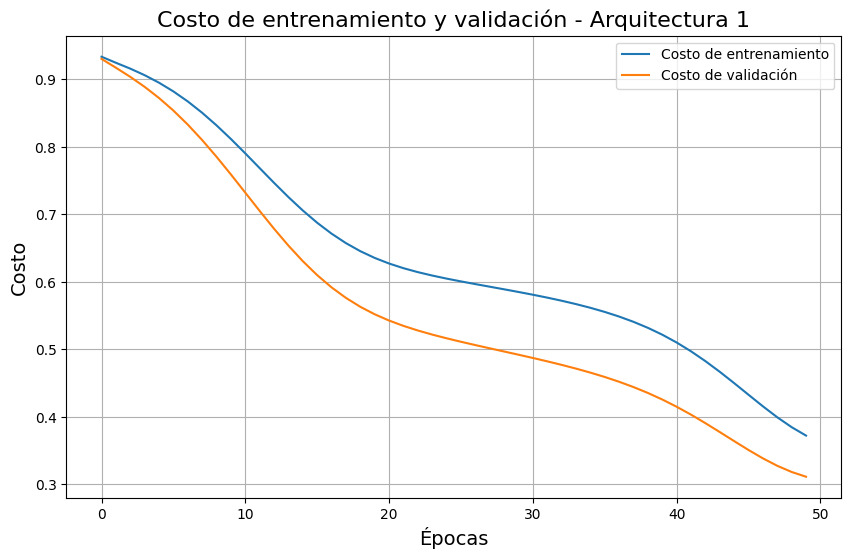

In [41]:
# Gráfica de costo de entrenamiento y validación
plot_cost(history_cost_train_arq1, history_cost_val_arq1, arquitecture)

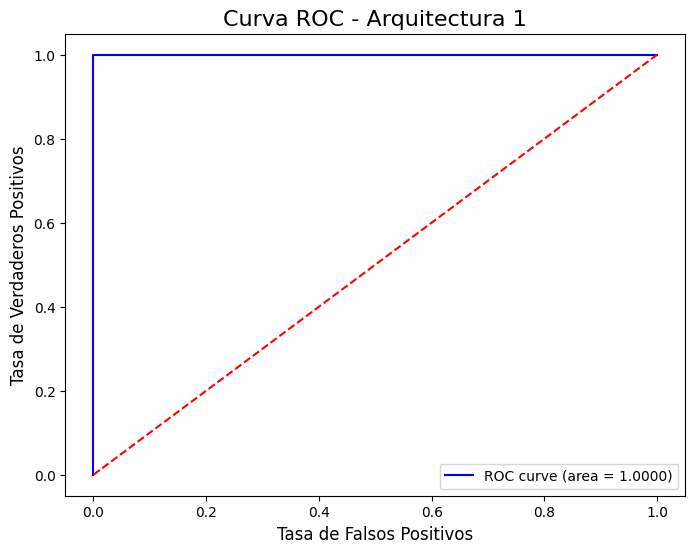

In [42]:
# gráfica roc
fpr, tpr, thresholds = roc_curve(y_val, [quantum_circuit(x, best_weights_arq1, arquitecture=1) for x in X_val])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title(f'Curva ROC - Arquitectura {arquitecture}', fontsize=16)
plt.xlabel('Tasa de Falsos Positivos', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos', fontsize=12)
plt.legend(loc='lower right')
plt.show()

In [43]:
# Evaluamos el desempeño del modelo en el conjunto de test
evaluate_test_set(best_weights_arq1, X_test, y_test, arquitecture)

Test loss: 0.3050 - Test accuracy: 1.0000 - Test AUC: 1.0000


In [44]:
import seaborn as sns

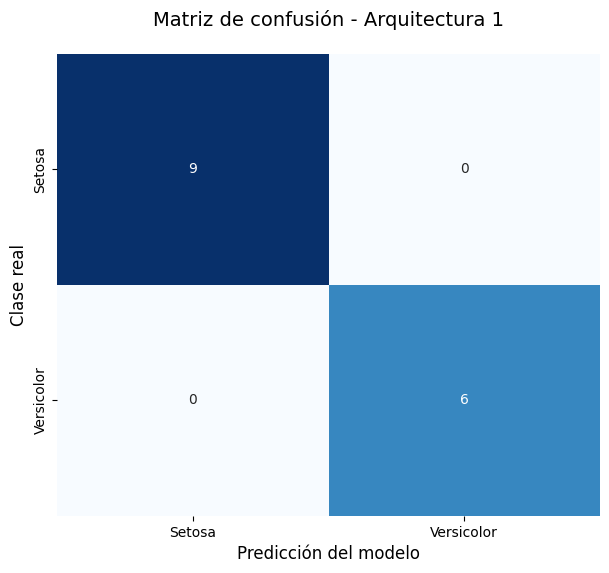

In [45]:
# matriz de confusión
plot_confusion_matrix(y_test, X_test, best_weights_arq1, arquitecture)

#### Arquitectura 2: Entre los dos pares de valores de correlación más altos

In [46]:
# hiperparámetros
n_iterations = 50
batch_size = 16
learning_rate = 0.01
weights = 0.01*np.random.rand(n_qubits, 2, requires_grad=True)
#delta = 0.005

# arquitectura a entrenar
arquitecture = 2

In [47]:
# Entrenamos el modelo con la arquitectura seleccionada
best_weights_arq2, history_cost_train_arq2, history_cost_val_arq2, history_acc_arq2, history_auc_arq2 = entrenamiento(arquitecture,
                                                                                                  learning_rate,
                                                                                                    weights,
                                                                                                    (X_train, y_train),
                                                                                                    (X_val, y_val),
                                                                                                    epochs=n_iterations,
                                                                                                    batch_size=batch_size,
                                                                                                    delta=delta)

Iniciando entrenamiento de la arquitectura 2...
Epoch 1/50: train_loss: 0.9331 - val_loss: 0.9294 - accuracy: 0.4000 - auc: 0.5536
Mejores pesos actualizados en epoch 5: val_loss 0.8703 - accuracy 0.4667 - AUC 0.6429
Epoch 6/50: train_loss: 0.8805 - val_loss: 0.8514 - accuracy: 0.4667 - auc: 0.7321
Mejores pesos actualizados en epoch 8: val_loss 0.8073 - accuracy 0.4667 - AUC 0.7679
Mejores pesos actualizados en epoch 10: val_loss 0.7561 - accuracy 0.7333 - AUC 0.9643
Epoch 11/50: train_loss: 0.7880 - val_loss: 0.7291 - accuracy: 0.8000 - auc: 0.9643
Mejores pesos actualizados en epoch 12: val_loss 0.7021 - accuracy 0.8000 - AUC 1.0000
Mejores pesos actualizados en epoch 14: val_loss 0.6510 - accuracy 0.8667 - AUC 1.0000
Epoch 16/50: train_loss: 0.6857 - val_loss: 0.6078 - accuracy: 0.8667 - auc: 1.0000
Mejores pesos actualizados en epoch 17: val_loss 0.5899 - accuracy 0.8667 - AUC 1.0000
Epoch 21/50: train_loss: 0.6262 - val_loss: 0.5415 - accuracy: 0.8667 - auc: 1.0000
Mejores pesos 

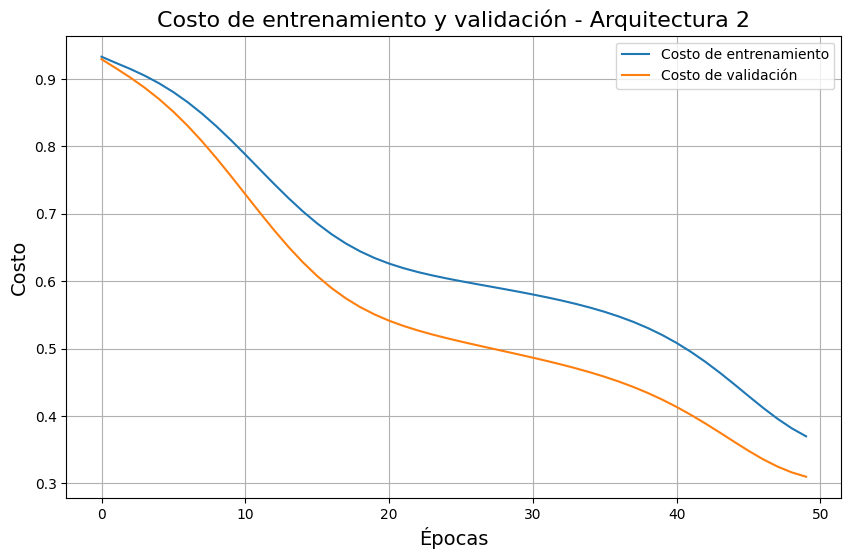

In [48]:
# Gráfica de costo de entrenamiento y validación
plot_cost(history_cost_train_arq2, history_cost_val_arq2, arquitecture)

In [49]:
# Evaluamos el desempeño del modelo en el conjunto de test
evaluate_test_set(best_weights_arq2, X_test, y_test, arquitecture)

Test loss: 0.3049 - Test accuracy: 1.0000 - Test AUC: 1.0000


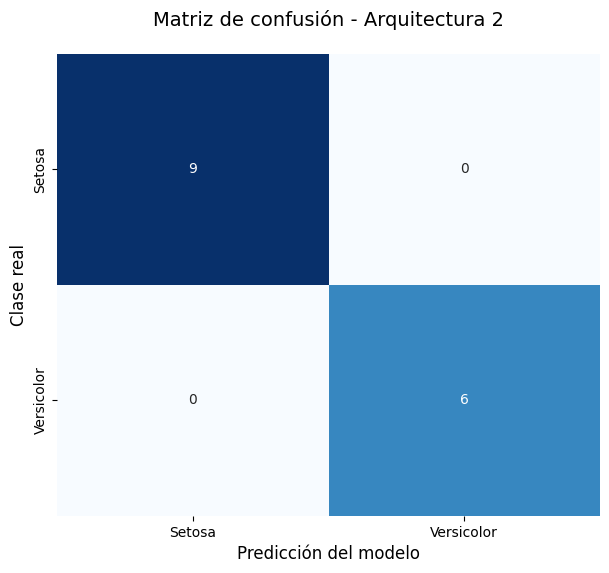

In [50]:
# matriz de confusión
plot_confusion_matrix(y_test, X_test, best_weights_arq2, arquitecture)

#### Arquitectura 3: Completamente entrelazada

In [51]:
# hiperparámetros
n_iterations = 50
batch_size = 16
learning_rate = 0.01
weights = 0.01*np.random.rand(n_qubits, 2, requires_grad=True)
#delta = 0.005

# arquitectura a entrenar
arquitecture = 3

In [52]:
# Entrenamos el modelo con la arquitectura seleccionada
best_weights_arq3, history_cost_train_arq3, history_cost_val_arq3, history_acc_arq3, history_auc_arq3 = entrenamiento(arquitecture,
                                                                                                  learning_rate,
                                                                                                    weights,
                                                                                                    (X_train, y_train),
                                                                                                    (X_val, y_val),
                                                                                                    epochs=n_iterations,
                                                                                                    batch_size=batch_size,
                                                                                                    delta=delta)

Iniciando entrenamiento de la arquitectura 3...
Epoch 1/50: train_loss: 3.1116 - val_loss: 3.2068 - accuracy: 0.0000 - auc: 0.0000
Mejores pesos actualizados en epoch 3: val_loss 3.1433 - accuracy 0.0000 - AUC 0.0000
Mejores pesos actualizados en epoch 4: val_loss 3.0914 - accuracy 0.0000 - AUC 0.0000
Mejores pesos actualizados en epoch 5: val_loss 3.0249 - accuracy 0.0000 - AUC 0.0000
Epoch 6/50: train_loss: 2.7672 - val_loss: 2.9440 - accuracy: 0.0000 - auc: 0.0000
Mejores pesos actualizados en epoch 6: val_loss 2.9440 - accuracy 0.0000 - AUC 0.0000
Mejores pesos actualizados en epoch 7: val_loss 2.8492 - accuracy 0.0667 - AUC 0.0000
Mejores pesos actualizados en epoch 8: val_loss 2.7421 - accuracy 0.0667 - AUC 0.0000
Mejores pesos actualizados en epoch 9: val_loss 2.6250 - accuracy 0.0667 - AUC 0.0000
Mejores pesos actualizados en epoch 10: val_loss 2.5006 - accuracy 0.1333 - AUC 0.0000
Epoch 11/50: train_loss: 2.1360 - val_loss: 2.3721 - accuracy: 0.1333 - auc: 0.0000
Mejores pesos

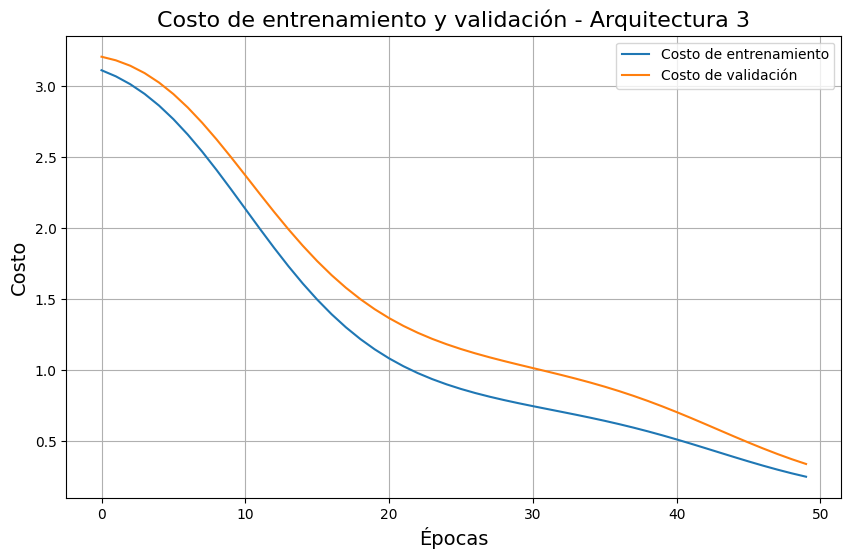

In [53]:
# Gráfica de costo de entrenamiento y validación
plot_cost(history_cost_train_arq3, history_cost_val_arq3, arquitecture)

In [54]:
# Evaluamos el desempeño del modelo en el conjunto de test
evaluate_test_set(best_weights_arq3, X_test, y_test, arquitecture)

Test loss: 0.2955 - Test accuracy: 1.0000 - Test AUC: 1.0000


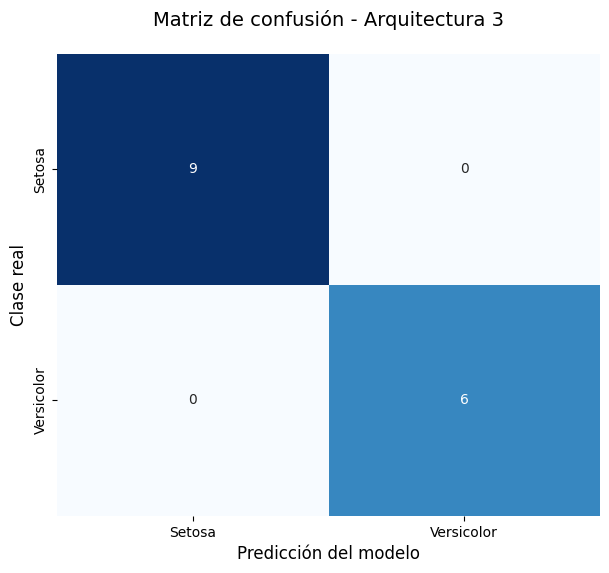

In [55]:
# matriz de confusión
plot_confusion_matrix(y_test, X_test, best_weights_arq3, arquitecture)

#### Arquitectura 4: Solo entrelazada donde la correlación tiende a 0, es decir, entre sepal length y sepal width ([0, 1])

In [56]:
# hiperparámetros
n_iterations = 50
batch_size = 16
learning_rate = 0.01
weights = 0.01*np.random.rand(n_qubits, 2, requires_grad=True)
#delta = 0.005

# arquitectura a entrenar
arquitecture = 4

In [57]:
# Entrenamos el modelo con la arquitectura seleccionada
best_weights_arq4, history_cost_train_arq4, history_cost_val_arq4, history_acc_arq4, history_auc_arq4 = entrenamiento(arquitecture,
                                                                                                  learning_rate,
                                                                                                    weights,
                                                                                                    (X_train, y_train),
                                                                                                    (X_val, y_val),
                                                                                                    epochs=n_iterations,
                                                                                                    batch_size=batch_size,
                                                                                                    delta=delta)

Iniciando entrenamiento de la arquitectura 4...
Epoch 1/50: train_loss: 0.7480 - val_loss: 0.6085 - accuracy: 0.8000 - auc: 0.8929
Epoch 6/50: train_loss: 0.7022 - val_loss: 0.5742 - accuracy: 0.8000 - auc: 0.9286
Epoch 11/50: train_loss: 0.6738 - val_loss: 0.5762 - accuracy: 0.8000 - auc: 0.9643
Epoch 16/50: train_loss: 0.6447 - val_loss: 0.5884 - accuracy: 0.8667 - auc: 0.9643
Epoch 21/50: train_loss: 0.6175 - val_loss: 0.6027 - accuracy: 0.8667 - auc: 0.9643
Epoch 26/50: train_loss: 0.5942 - val_loss: 0.6138 - accuracy: 0.8667 - auc: 0.9821
Epoch 31/50: train_loss: 0.5747 - val_loss: 0.6194 - accuracy: 0.7333 - auc: 1.0000
Epoch 36/50: train_loss: 0.5586 - val_loss: 0.6205 - accuracy: 0.6667 - auc: 1.0000
Epoch 41/50: train_loss: 0.5460 - val_loss: 0.6190 - accuracy: 0.6667 - auc: 1.0000
Epoch 46/50: train_loss: 0.5367 - val_loss: 0.6168 - accuracy: 0.6667 - auc: 1.0000
Entrenamiento completado en 122.96 segundos.


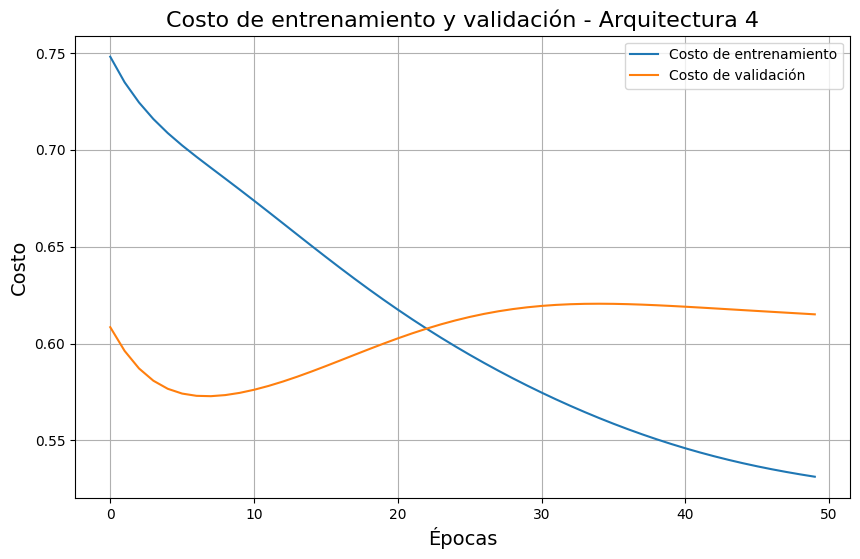

In [58]:
# Gráfica de costo de entrenamiento y validación
plot_cost(history_cost_train_arq4, history_cost_val_arq4, arquitecture)

In [59]:
# Evaluamos el desempeño del modelo en el conjunto de test
evaluate_test_set(best_weights_arq4, X_test, y_test, arquitecture)

Test loss: 0.5475 - Test accuracy: 0.8667 - Test AUC: 1.0000


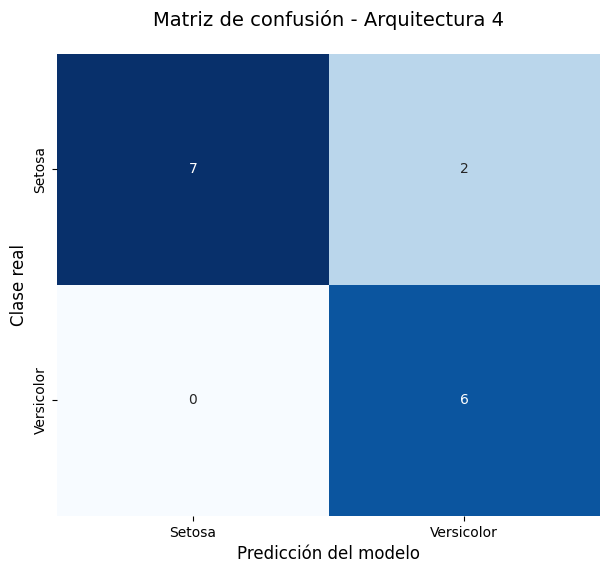

In [60]:
# matriz de confusión
plot_confusion_matrix(y_test, X_test, best_weights_arq4, arquitecture)

### Modelos con ruido

Como ahora compararemos 3 niveles de ruido, crearemos una función adicional para el entrenamiento completo con cada nivel de ruido. Esto nos permitirá evaluar el rendimiento del modelo de clasificación bajo diferentes condiciones de ruido y comparar cómo afecta el ruido a la capacidad del modelo para aprender a clasificar las especies de iris.

#### Arquitectura 1: Solo entrelazamiento entre petal length y petal width

In [61]:
# hiperparámetros
n_iterations = 100
batch_size = 16
learning_rate = 0.01
weights = 0.01*np.random.rand(n_qubits, 2, requires_grad=True)
delta = 0.05
epochs_sin_mejor_peso = 20

# arquitectura a entrenar
arquitecture = 1
modelo = quantum_model_noise

In [62]:
# Entrenamiento del modelo con arquitecrura 1
best_weights_noise1, history_cost_train_noise1, history_cost_val_noise1, history_acc_noise1, history_auc_noise1 = entrenamiento(arquitecture,
                                                                                                  learning_rate, 
                                                                                                  weights, 
                                                                                                  (X_train, y_train), 
                                                                                                  (X_val, y_val), 
                                                                                                  epochs=n_iterations, 
                                                                                                  batch_size=batch_size,
                                                                                                  delta=delta,
                                                                                                  epochs_sin_mejor_peso=epochs_sin_mejor_peso,
                                                                                                  model_func=modelo)

Iniciando entrenamiento de la arquitectura 1...
Epoch 1/100: train_loss: 0.9339 - val_loss: 0.9309 - accuracy: 0.4000 - auc: 0.5536
Mejores pesos actualizados en epoch 5: val_loss 0.8726 - accuracy 0.4667 - AUC 0.6429
Epoch 6/100: train_loss: 0.8823 - val_loss: 0.8540 - accuracy: 0.4667 - auc: 0.7143
Mejores pesos actualizados en epoch 8: val_loss 0.8103 - accuracy 0.4667 - AUC 0.7500
Mejores pesos actualizados en epoch 10: val_loss 0.7594 - accuracy 0.7333 - AUC 0.9464
Epoch 11/100: train_loss: 0.7906 - val_loss: 0.7324 - accuracy: 0.7333 - auc: 0.9643
Mejores pesos actualizados en epoch 12: val_loss 0.7054 - accuracy 0.8000 - AUC 0.9821
Mejores pesos actualizados en epoch 14: val_loss 0.6539 - accuracy 0.8667 - AUC 1.0000
Epoch 16/100: train_loss: 0.6878 - val_loss: 0.6101 - accuracy: 0.8667 - auc: 1.0000
Mejores pesos actualizados en epoch 17: val_loss 0.5919 - accuracy 0.8667 - AUC 1.0000
Epoch 21/100: train_loss: 0.6272 - val_loss: 0.5426 - accuracy: 0.8667 - auc: 1.0000
Mejores p

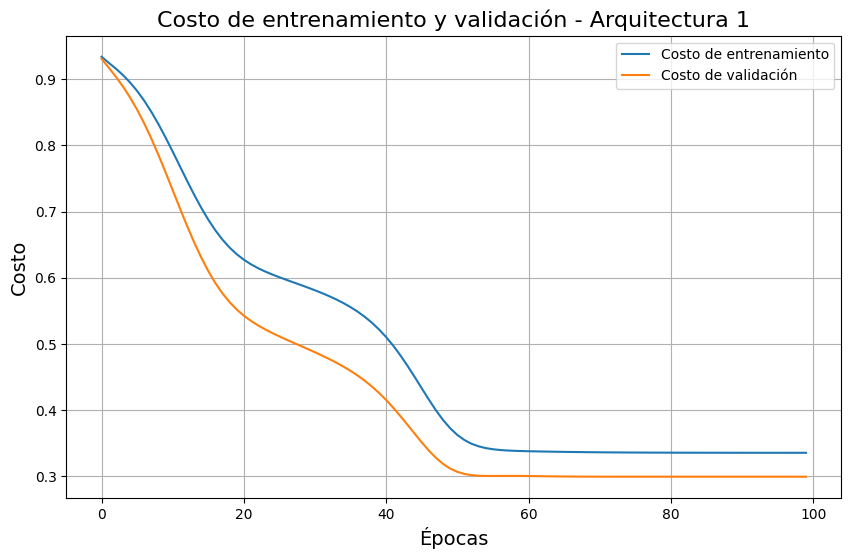

In [63]:
# Gráfica de costo de entrenamiento y validación
plot_cost(history_cost_train_noise1, history_cost_val_noise1, arquitecture)

In [64]:
# Evaluamos el desempeño del modelo en el conjunto de test
evaluate_test_set(best_weights_noise1, X_test, y_test, arquitecture)

Test loss: 0.3050 - Test accuracy: 1.0000 - Test AUC: 1.0000


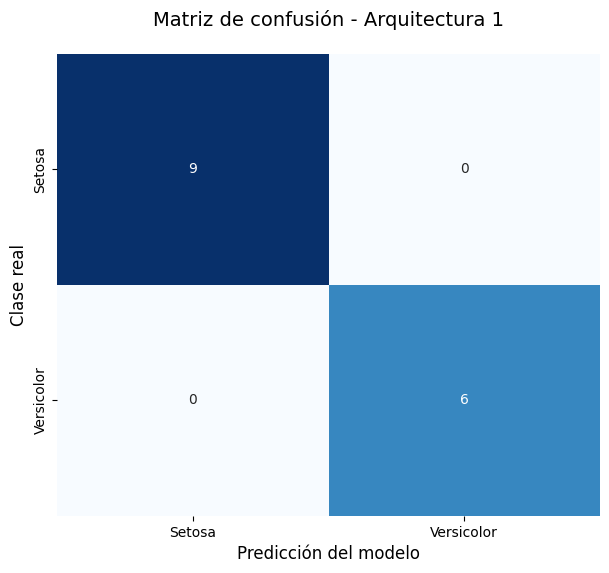

In [65]:
# matriz de confusión
plot_confusion_matrix(y_test, X_test, best_weights_noise1, arquitecture)

#### Arquitectura 2: Entre los dos pares de valores de correlación más altos

In [66]:
# hiperparámetros
n_iterations = 100
batch_size = 16
learning_rate = 0.01
weights = 0.01*np.random.rand(n_qubits, 2, requires_grad=True)
#delta = 0.05
epochs_sin_mejor_peso = 20

# arquitectura a entrenar
arquitecture = 2
modelo = quantum_model_noise

In [67]:
# entrenamos el modelo con la arquitectura seleccionada
best_weights_noise2, history_cost_train_noise2, history_cost_val_noise2, history_acc_noise2, history_auc_noise2 = entrenamiento(arquitecture,
                                                                                                                                learning_rate,
                                                                                                                                weights,
                                                                                                                                (X_train, y_train),
                                                                                                                                (X_val, y_val),
                                                                                                                                epochs=n_iterations,
                                                                                                                                batch_size=batch_size,
                                                                                                                                delta=delta,
                                                                                                                                epochs_sin_mejor_peso=epochs_sin_mejor_peso,
                                                                                                                                model_func=modelo)

Iniciando entrenamiento de la arquitectura 2...
Epoch 1/100: train_loss: 0.9338 - val_loss: 0.9308 - accuracy: 0.4000 - auc: 0.5536
Mejores pesos actualizados en epoch 5: val_loss 0.8723 - accuracy 0.4667 - AUC 0.6429
Epoch 6/100: train_loss: 0.8820 - val_loss: 0.8536 - accuracy: 0.4667 - auc: 0.7143
Mejores pesos actualizados en epoch 8: val_loss 0.8098 - accuracy 0.4667 - AUC 0.7500
Mejores pesos actualizados en epoch 10: val_loss 0.7588 - accuracy 0.7333 - AUC 0.9643
Epoch 11/100: train_loss: 0.7900 - val_loss: 0.7318 - accuracy: 0.7333 - auc: 0.9643
Mejores pesos actualizados en epoch 12: val_loss 0.7047 - accuracy 0.8000 - AUC 1.0000
Mejores pesos actualizados en epoch 14: val_loss 0.6534 - accuracy 0.8667 - AUC 1.0000
Epoch 16/100: train_loss: 0.6873 - val_loss: 0.6097 - accuracy: 0.8667 - auc: 1.0000
Mejores pesos actualizados en epoch 17: val_loss 0.5916 - accuracy 0.8667 - AUC 1.0000
Epoch 21/100: train_loss: 0.6271 - val_loss: 0.5426 - accuracy: 0.8667 - auc: 1.0000
Mejores p

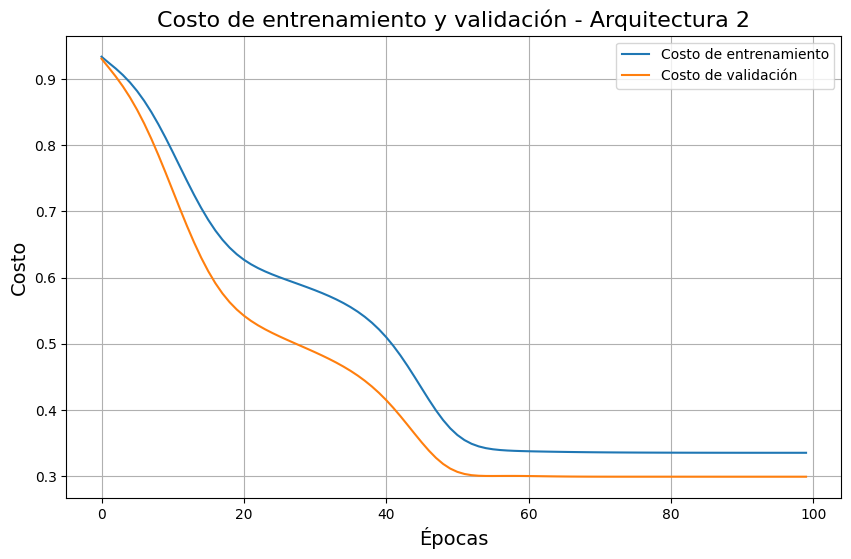

In [68]:
# Gráfica de costo de entrenamiento y validación
plot_cost(history_cost_train_noise2, history_cost_val_noise2, arquitecture)

In [69]:
# Evaluamos el desempeño del modelo en el conjunto de test
evaluate_test_set(best_weights_noise2, X_test, y_test, arquitecture)

Test loss: 0.3050 - Test accuracy: 1.0000 - Test AUC: 1.0000


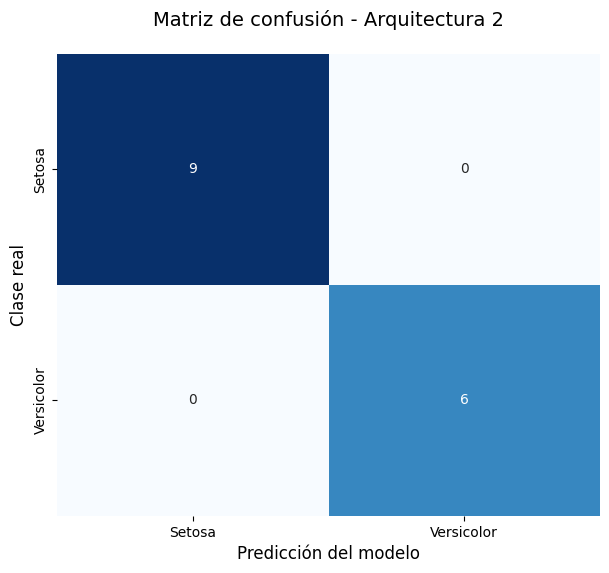

In [70]:
# matriz de confusión
plot_confusion_matrix(y_test, X_test, best_weights_noise2, arquitecture)

#### Arquitectura 3: Completamente entrelazada

In [71]:
# hiperparámetros
n_iterations = 100
batch_size = 16
learning_rate = 0.01
weights = 0.01*np.random.rand(n_qubits, 2, requires_grad=True)
#delta = 0.05
epochs_sin_mejor_peso = 20

# arquitectura a entrenar
arquitecture = 3
modelo = quantum_model_noise

In [73]:
# Entrenamiento del modelo cuántico
best_weights_noise3, history_cost_train_noise3, history_cost_val_noise3, history_acc_noise3, history_auc_noise3 = entrenamiento(arquitecture,
                                                                                                                                learning_rate,
                                                                                                                                weights,
                                                                                                                                (X_train, y_train),
                                                                                                                                (X_val, y_val),
                                                                                                                                epochs=n_iterations,
                                                                                                                                batch_size=batch_size,
                                                                                                                                delta=delta,
                                                                                                                                epochs_sin_mejor_peso=epochs_sin_mejor_peso,
                                                                                                                                model_func=modelo)

Iniciando entrenamiento de la arquitectura 3...
Epoch 1/100: train_loss: 3.1184 - val_loss: 3.2099 - accuracy: 0.0000 - auc: 0.0000
Mejores pesos actualizados en epoch 3: val_loss 3.1500 - accuracy 0.0000 - AUC 0.0000
Mejores pesos actualizados en epoch 4: val_loss 3.1000 - accuracy 0.0000 - AUC 0.0000
Mejores pesos actualizados en epoch 5: val_loss 3.0353 - accuracy 0.0000 - AUC 0.0000
Epoch 6/100: train_loss: 2.7826 - val_loss: 2.9559 - accuracy: 0.0000 - auc: 0.0000
Mejores pesos actualizados en epoch 6: val_loss 2.9559 - accuracy 0.0000 - AUC 0.0000
Mejores pesos actualizados en epoch 7: val_loss 2.8624 - accuracy 0.0667 - AUC 0.0000
Mejores pesos actualizados en epoch 8: val_loss 2.7562 - accuracy 0.0667 - AUC 0.0000
Mejores pesos actualizados en epoch 9: val_loss 2.6397 - accuracy 0.0667 - AUC 0.0000
Mejores pesos actualizados en epoch 10: val_loss 2.5154 - accuracy 0.1333 - AUC 0.0000
Epoch 11/100: train_loss: 2.1533 - val_loss: 2.3866 - accuracy: 0.1333 - auc: 0.0000
Mejores pe

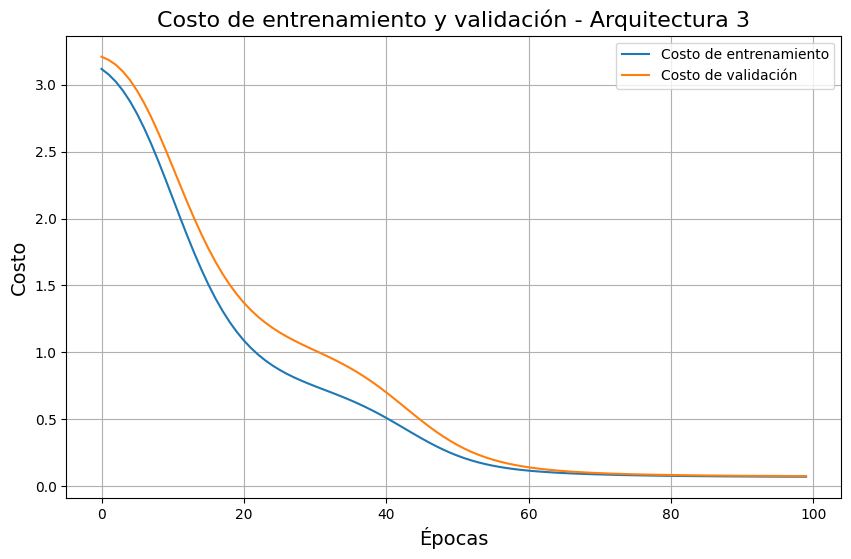

In [74]:
# Gráfica de costo de entrenamiento y validación
plot_cost(history_cost_train_noise3, history_cost_val_noise3, arquitecture)

In [75]:
#Evaluamos el desempeño del modelo en el conjunto de test
evaluate_test_set(best_weights_noise3, X_test, y_test, arquitecture)

Test loss: 0.0535 - Test accuracy: 1.0000 - Test AUC: 1.0000


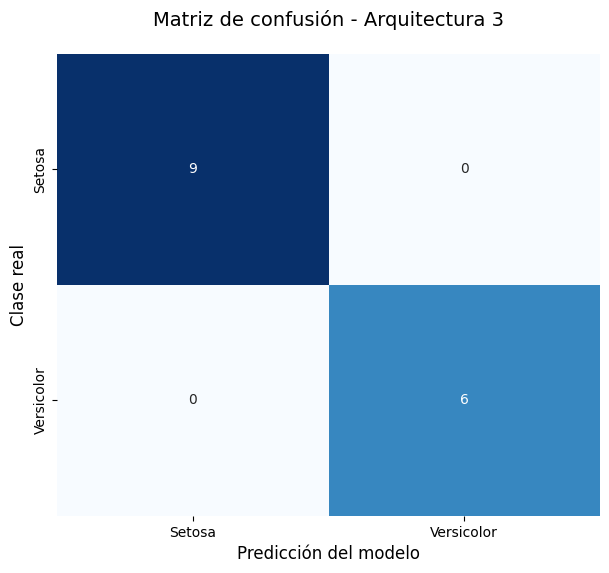

In [76]:
# Matriz de confusión
plot_confusion_matrix(y_test, X_test, best_weights_noise3, arquitecture)

#### Aquitectura 4: Solo entrelazada donde la correlación tiende a 0, es decir, entre sepal length y sepal width ([0, 1])

In [77]:
# hiperparámetros
n_iterations = 100
batch_size = 16
learning_rate = 0.01
weights = 0.01*np.random.rand(n_qubits, 2, requires_grad=True)
#delta = 0.05  
epochs_sin_mejor_peso = 20

# arquitectura a entrenar
arquitecture = 4
modelo = quantum_model_noise

In [79]:
# Entrenamiento del modelo cuántico
best_weights_noise4, history_cost_train_noise4, history_cost_val_noise4, history_acc_noise4, history_auc_noise4 = entrenamiento(arquitecture,
                                                                                                                                learning_rate,
                                                                                                                                weights,
                                                                                                                                (X_train, y_train),
                                                                                                                                (X_val, y_val),
                                                                                                                                epochs_sin_mejor_peso=epochs_sin_mejor_peso,
                                                                                                                                epochs=n_iterations,
                                                                                                                                batch_size=batch_size,
                                                                                                                                delta=delta,
                                                                                                                                model_func=modelo)

Iniciando entrenamiento de la arquitectura 4...
Epoch 1/100: train_loss: 0.7477 - val_loss: 0.6080 - accuracy: 0.8000 - auc: 0.8929
Epoch 6/100: train_loss: 0.7022 - val_loss: 0.5741 - accuracy: 0.8000 - auc: 0.9286
Epoch 11/100: train_loss: 0.6738 - val_loss: 0.5761 - accuracy: 0.8000 - auc: 0.9643
Epoch 16/100: train_loss: 0.6447 - val_loss: 0.5884 - accuracy: 0.8667 - auc: 0.9643
Epoch 21/100: train_loss: 0.6175 - val_loss: 0.6027 - accuracy: 0.8667 - auc: 0.9643
Epoch 26/100: train_loss: 0.5942 - val_loss: 0.6138 - accuracy: 0.8667 - auc: 0.9821
Epoch 31/100: train_loss: 0.5747 - val_loss: 0.6194 - accuracy: 0.7333 - auc: 1.0000
Epoch 36/100: train_loss: 0.5586 - val_loss: 0.6205 - accuracy: 0.6667 - auc: 1.0000
Epoch 41/100: train_loss: 0.5460 - val_loss: 0.6190 - accuracy: 0.6667 - auc: 1.0000
Epoch 46/100: train_loss: 0.5367 - val_loss: 0.6168 - accuracy: 0.6667 - auc: 1.0000
Epoch 51/100: train_loss: 0.5302 - val_loss: 0.6146 - accuracy: 0.6667 - auc: 1.0000
Epoch 56/100: train

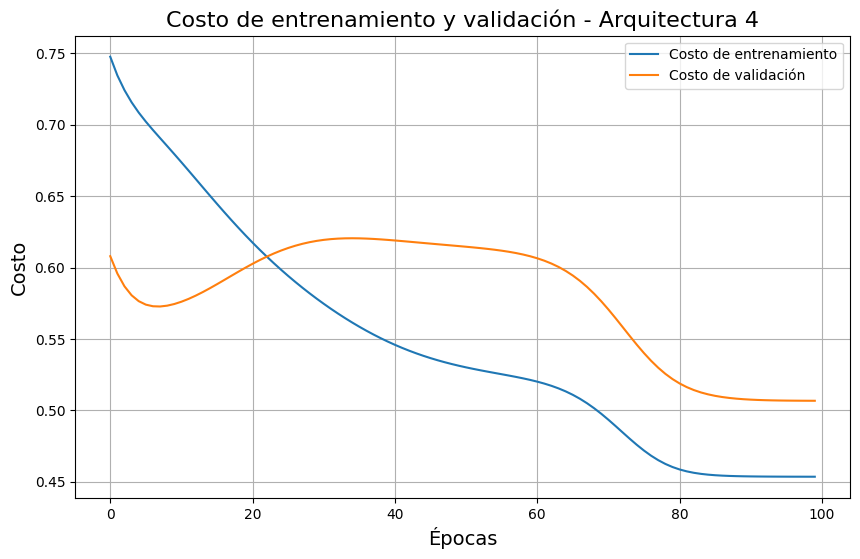

In [80]:
#Gráfica de costo de entrenamiento y validación
plot_cost(history_cost_train_noise4, history_cost_val_noise4, arquitecture)

In [81]:
# Evaluamos el desempeño del modelo en el conjunto de test
evaluate_test_set(best_weights_noise4, X_test, y_test, arquitecture)

Test loss: 0.6330 - Test accuracy: 0.9333 - Test AUC: 1.0000


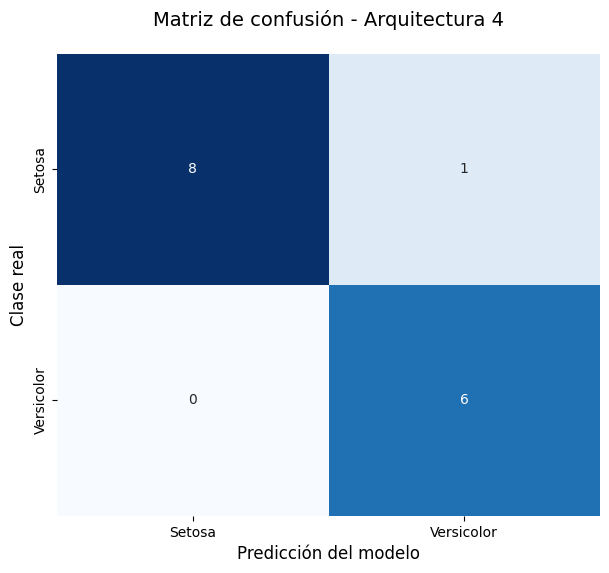

In [82]:
# matriz de confusión
plot_confusion_matrix(y_test, X_test, best_weights_noise4, arquitecture)

Algo que podemos ver es que tanto en los modelos sin ruido como en lo modelos con ruido la arquitectura completamente entrelazada ha tenido un mejor desempeño, lo que sugiere que el entrelazamiento completo puede ser beneficioso para la clasificación de las especies de iris. Esto podría deberse a que el entrelazamiento completo permite que el modelo capture mejor las relaciones complejas entre las características, lo que puede mejorar la capacidad del modelo para distinguir entre las diferentes clases. Sin embargo, es importante tener en cuenta que el rendimiento del modelo también puede depender de otros factores, como la cantidad de ruido presente y la configuración específica del circuito cuántico variacional. Por lo tanto, es crucial realizar una evaluación cuidadosa y considerar múltiples métricas de rendimiento para obtener una comprensión completa del desempeño del modelo.

### Arquitectura con dispositivo real simulado de quiskit

Despues de las pruebas usaremos un dispositivo real simulado de quiskit para evaluar el rendimiento del modelo en condiciones más cercanas a las de un dispositivo cuántico real. Esto nos permitirá entender mejor cómo se comporta el modelo de clasificación en un entorno con ruido y limitaciones similares a las de un dispositivo cuántico real, lo que es crucial para evaluar la viabilidad del modelo para aplicaciones prácticas en el futuro.

Usaremos fake_provider de quiskit para simular un dispositivo real.

In [94]:
from pennylane_qiskit import qiskit_device
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit_aer import noise, AerSimulator

In [96]:
backend = FakeManilaV2()
model_noise = noise.NoiseModel.from_backend(backend)

dev_real_noise = qml.device(name='qiskit.aer', 
                            wires=n_qubits,
                            noise = model_noise,
                            backend = 'aer_simulator_density_matrix')

@qml.qnode(dev_real_noise)
def quantum_model_real_noise(input_data, params, arquitecture):
    feature_map(input_data)
    ansatz(params, arquitecture)
    return qml.expval(qml.PauliZ(0))

#### Arquitectura 1: Solo entrelazamiento entre petal length y petal width

In [106]:
#hiperparámetros
n_iterations = 100
batch_size = 16
learning_rate = 0.01
weights = 0.01*np.random.rand(n_qubits, 2, requires_grad=True)
delta = 0.05
epochs_sin_mejor_peso = 20
# arquitectura a entrenar
arquitecture = 1
modelo = quantum_model_real_noise

In [107]:
# Entrenamiento del modelo cuántico
best_weights_real_noise1, history_cost_train_real_noise1, history_cost_val_real_noise1, history_acc_real_noise1, history_auc_real_noise1 = entrenamiento(arquitecture,
                                                                                                                                learning_rate,
                                                                                                                                weights,
                                                                                                                                (X_train, y_train),
                                                                                                                                (X_val, y_val),
                                                                                                                                epochs=n_iterations,
                                                                                                                                batch_size=batch_size,
                                                                                                                                delta=delta,
                                                                                                                                epochs_sin_mejor_peso=epochs_sin_mejor_peso,
                                                                                                                                model_func=modelo)

Iniciando entrenamiento de la arquitectura 1...


c:\Users\jltg_\Documents\Física\quantum_computing\pennylane\.venv\Lib\site-packages\pennylane_qiskit\qiskit_device_legacy.py:144: UserWarning: The analytic calculation of expectations, variances and probabilities is only supported on statevector backends, not on the aer_simulator_density_matrix. Such statistics obtained from this device are estimates based on samples.
  warnings.warn(self.analytic_warning_message.format(self.backend_name), UserWarning)


Epoch 1/100: train_loss: 0.9329 - val_loss: 0.9292 - accuracy: 0.4667 - auc: 0.5893
Mejores pesos actualizados en epoch 5: val_loss 0.8699 - accuracy 0.4667 - AUC 0.6429
Epoch 6/100: train_loss: 0.8802 - val_loss: 0.8510 - accuracy: 0.5333 - auc: 0.7500
Mejores pesos actualizados en epoch 8: val_loss 0.8067 - accuracy 0.6000 - AUC 0.7857
Mejores pesos actualizados en epoch 10: val_loss 0.7554 - accuracy 0.6667 - AUC 0.8214
Epoch 11/100: train_loss: 0.7874 - val_loss: 0.7284 - accuracy: 0.7333 - auc: 0.9821
Mejores pesos actualizados en epoch 12: val_loss 0.7014 - accuracy 0.9333 - AUC 1.0000
Mejores pesos actualizados en epoch 14: val_loss 0.6504 - accuracy 0.8000 - AUC 1.0000
Epoch 16/100: train_loss: 0.6853 - val_loss: 0.6073 - accuracy: 0.8000 - auc: 1.0000
Mejores pesos actualizados en epoch 17: val_loss 0.5895 - accuracy 0.8667 - AUC 1.0000
Epoch 21/100: train_loss: 0.6261 - val_loss: 0.5414 - accuracy: 0.9333 - auc: 1.0000
Mejores pesos actualizados en epoch 22: val_loss 0.5337 -

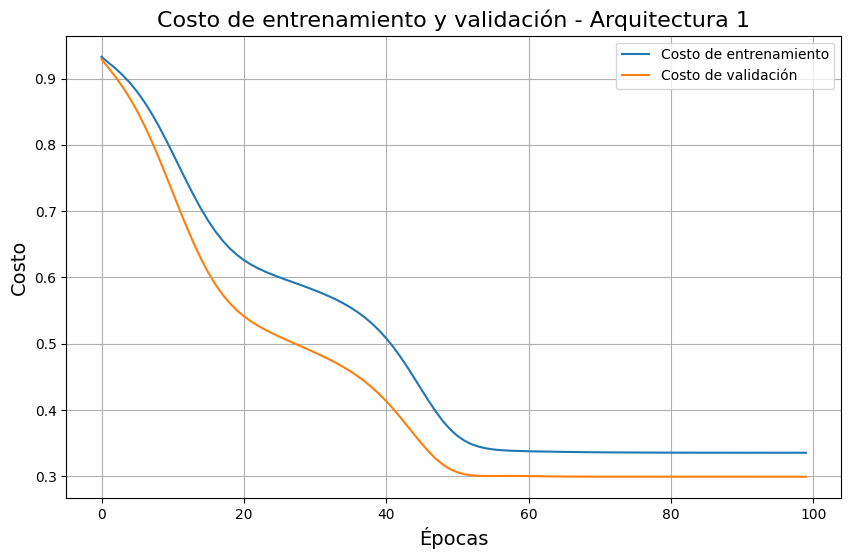

In [108]:
# gráfica de costo de entrenamiento y validación
plot_cost(history_cost_train_real_noise1, history_cost_val_real_noise1, arquitecture)

In [109]:
# Evaluamos el desempeño del modelo en el conjunto de test
evaluate_test_set(best_weights_real_noise1, X_test, y_test, arquitecture)

Test loss: 0.3045 - Test accuracy: 1.0000 - Test AUC: 1.0000


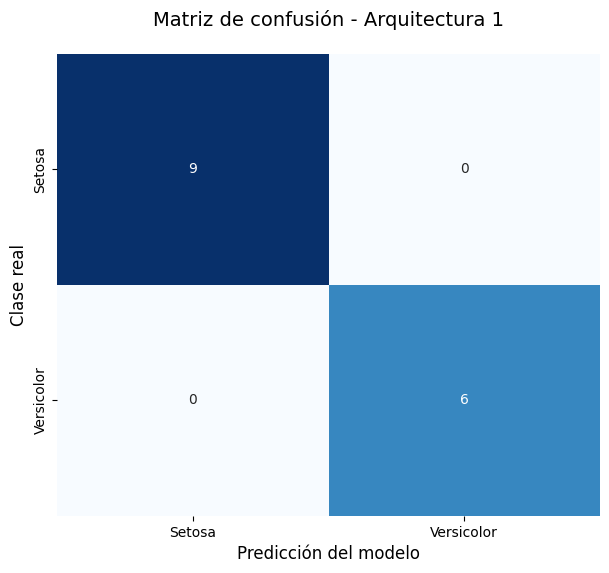

In [111]:
# Matriz de confusión
plot_confusion_matrix(y_test, X_test, best_weights_real_noise1, arquitecture)

#### Arquitectura 3: Completamente entrelazada

In [ ]:
# hiperparámetros
n_iterations = 100
batch_size = 16
learning_rate = 0.001
weights = 0.01*np.random.rand(n_qubits, 2, requires_grad=True)
delta = 0.1
epochs_sin_mejor_peso = 25

# arquitectura a entrenar
arquitecture = 3
modelo = quantum_model_real_noise

In [102]:
# Entrenamiento del modelo cuántico
best_weights_r_noise, history_cost_train_r_noise, history_cost_val_r_noise, history_acc_r_noise, history_auc_r_noise = entrenamiento(arquitecture,
                                                                                                                                learning_rate,
                                                                                                                                weights,
                                                                                                                                (X_train, y_train),
                                                                                                                                (X_val, y_val),
                                                                                                                                epochs=n_iterations,
                                                                                                                                batch_size=batch_size,
                                                                                                                                delta=delta,
                                                                                                                                epochs_sin_mejor_peso=epochs_sin_mejor_peso,
                                                                                                                                model_func=modelo)

Iniciando entrenamiento de la arquitectura 3...
Epoch 1/100: train_loss: 3.1224 - val_loss: 3.2163 - accuracy: 0.0000 - auc: 0.0000
Epoch 6/100: train_loss: 3.1031 - val_loss: 3.2081 - accuracy: 0.0000 - auc: 0.0000
Epoch 11/100: train_loss: 3.0795 - val_loss: 3.1958 - accuracy: 0.0000 - auc: 0.0000
Epoch 16/100: train_loss: 3.0511 - val_loss: 3.1787 - accuracy: 0.0000 - auc: 0.0000
Epoch 21/100: train_loss: 3.0178 - val_loss: 3.1567 - accuracy: 0.0000 - auc: 0.0000
Epoch 26/100: train_loss: 2.9799 - val_loss: 3.1300 - accuracy: 0.0000 - auc: 0.0000
Mejores pesos actualizados en epoch 29: val_loss 3.1119 - accuracy 0.0000 - AUC 0.0000
Epoch 31/100: train_loss: 2.9378 - val_loss: 3.0990 - accuracy: 0.0000 - auc: 0.0000
Epoch 36/100: train_loss: 2.8919 - val_loss: 3.0641 - accuracy: 0.0000 - auc: 0.0000
Epoch 41/100: train_loss: 2.8426 - val_loss: 3.0255 - accuracy: 0.0000 - auc: 0.0000
Mejores pesos actualizados en epoch 43: val_loss 3.0091 - accuracy 0.0000 - AUC 0.0000
Epoch 46/100: t

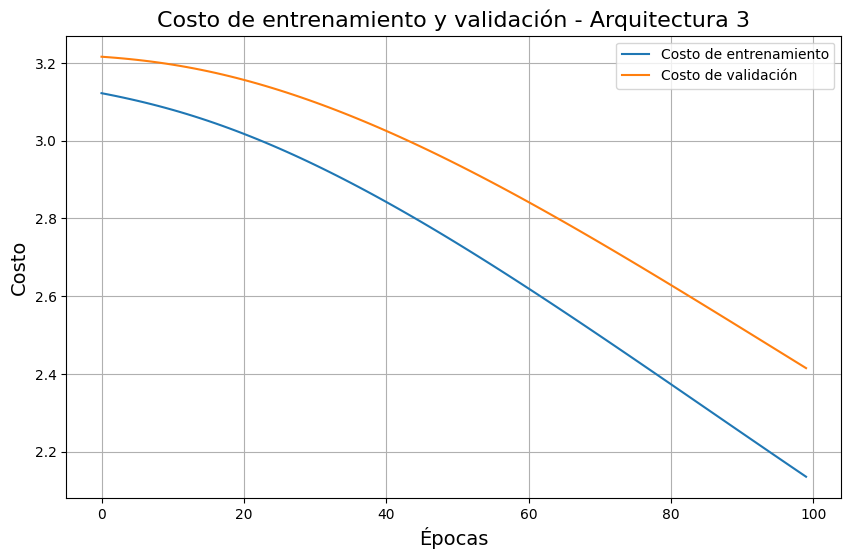

In [103]:
# gráfica de costo de entrenamiento y validación
plot_cost(history_cost_train_r_noise, history_cost_val_r_noise, arquitecture)

In [104]:
# Evaluamos el desempeño del modelo en el conjunto de test
evaluate_test_set(best_weights_r_noise, X_test, y_test, arquitecture)

Test loss: 2.5835 - Test accuracy: 0.1333 - Test AUC: 0.0000


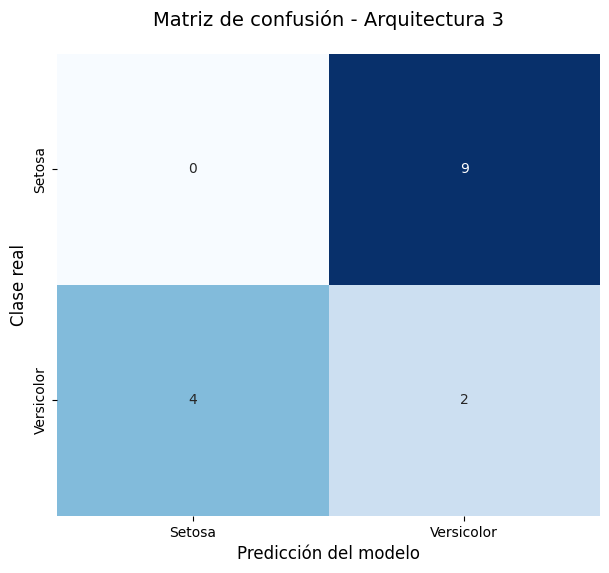

In [105]:
# Matriz de confusión
plot_confusion_matrix(y_test, X_test, best_weights_r_noise, arquitecture)

## Conclusiones

**Sobre los dispositivos sin ruido**

Podemos ver que en el caso de simuladores sin ruido tenemos grandes resutados, la convergencia es rápida, las métricas de evaluación son altas y la matriz de confusión muestra que el modelo clasifica correctamente, por lo menos, la mayoría de las muestras; mientras que en la mayorías de casos lograron clasificar bien todas las muestras. Esto sugiere que el modelo de clasificación es efectivo para distinguir entre las especies de iris cuando no hay ruido presente. Resaltando el modelo altamente entrelazado comparado por su valor de pérdida, no podemos compararlo solo por su valor de accuracy y auc ya que fueron igual a 1 en varias arquitecturas. El tiempo de entrenamiento rondó entre 122 s y 145 s.


**Sobre los dispositivos con ruido**

Por otro lado, al colocar un poco de ruido tenemos un resuldo similar. La arquitectura completamente entrelazada siguió mostrando los mejores resultado en las métricas de evaluación, sin embargo, el tiempo de entenamiento empezó a sobresalir respecto a las demás arquitecturas. Esto se puede deber a que al introducir ruido, el modelo tiene que manejar incertidumbre adicional que se ve reflejada en el uso de matrices de densidad en lugar de vectores de estado puros, lo que en principio, aumenta la cantidad de recursos computacionales y esto se ve reflejado en el tiempo de entrenamiento. Por otro lado, aquí es en donde la última arquitectura empieza a sufrir un poco; la arquitectura que entrelaza variables con baja correlación, mostró un desempeño algo menor a los otros 3 modelos, lo que sugiere que el entrelazamiento de características con baja correlación puede no ser tan efectivo para la clasificación de las especies de iris, especialmente en presencia de ruido. Esto podría deberse a que el entrelazamiento de características con baja correlación no captura tan bien las relaciones relevantes entre las características, lo que puede dificultar que el modelo aprenda a distinguir entre las diferentes clases, especialmente cuando hay ruido presente. Aquí los tiempos rondaron entre 330 s y 397 s.


**Sobre los dispositivos cuánticos simulados con base en computadoras reales**

Por último, cuando se trabajó con un simulador de una computadora cuántica real, solo se abordaron dos arquitecturas. la primera, donde se entrelazan las características con mayor correlación; y la segunda, donde se entrelazan todas las características. Aquí el tiempo de entrenamiento fue notablemente mayor para ambas arquitecturas, meintras que en las anteriores rondaban entre 2 minutos y 4 minutos por arquitectura aquí, con este dispositivo, el tiempo de entrenamiento subió hasta 1200 s, es decir, estas arquitecturas, con este dispositivo creció en 10 el tiempo de las primeras rondando los 20 minutos. Esto se puede deber a que el simulador de un dispositivo cuántico real incluye un modelo de ruido más complejo y realista, lo que puede aumentar significativamente la cantidad de recursos computacionales necesarios para simular el circuito cuántico variacional, especialmente cuando se trabaja con circuitos más complejos como el completamente entrelazado. Además, el simulador de un dispositivo cuántico real puede incluir limitaciones adicionales, como la fidelidad de las compuertas y la decoherencia, lo que también puede contribuir al aumento del tiempo de entrenamiento. En cuanto al desempeño del modelo, las cosas cambiaron drásticamente. El modelo altamente entrelazado mostró un muy bajo desempeño, el accuracy fue de 0.133 mientras que el AUc fue de 0.0, lo que indica que el modelo no fue capaz de aprender lascaracterística para poder clasificar las especies de iris salvo 2, sin embargo hubo un gran sesgo hacia la clase versicolor, misma donde el modelo logro acertar 2/15 elementos. 

Por otro lado, la primera arquitectura, es decir, la arquitectura donde se enfocó solamente en resaltar la correlación inicial encotrada, tuvo un muy buen desempeño con un accuracy y auc con valor igual a 1, mientras su valor de pérdida fue de 0.3045, lo que sugiere que el modelo fue capaz de aprender a clasificar las especies de iris de manera efectiva incluso en presencia de ruido realista. Esto podría deberse a que el entrelazamiento de características con alta correlación permitió que el modelo capturara mejor las relaciones relevantes entre las características, mientras que mantenerlo con menos compuertas facilitó el aprendizaje y la clasificación precisa de las especies de iris, incluso cuando se enfrentó a las limitaciones en el tamaño del dataset y el ruido presentes en un dispositivo cuántico real. En resumen, estos resultados destacan la importancia de seleccionar cuidadosamente las características y la arquitectura del circuito cuántico variacional para lograr un buen desempeño en tareas de clasificación, especialmente cuando se trabaja con dispositivos cuánticos reales que incluyen ruido y limitaciones adicionales.